# 08 -- LSTM: Red Neuronal Recurrente para Pronostico de Rentas Cedidas

**Sistema de Analisis y Pronostico de Rentas Cedidas** | ADRES -- Colombia

---

### Por que un cuaderno dedicado a LSTM

Tras modelos econometricos (SARIMAX), probabilisticos (Prophet) y de Machine
Learning (XGBoost), este cuaderno completa el espectro metodologico con
**Deep Learning**. Las redes LSTM (Hochreiter & Schmidhuber, 1997) son el
estandar para secuencias temporales en redes neuronales.

**Pregunta central:** Una red neuronal recurrente puede superar a modelos
mas simples cuando solo se dispone de 51 meses de datos?

## Arquitectura Analitica

| Fase | Contenido | Metodo | Pregunta que responde |
|------|-----------|--------|----------------------|
| **I** | Carga, preprocesamiento y normalizacion | log1p + MinMaxScaler | Datos listos para la red? |
| **II** | Construccion de ventanas temporales | look-back = 12 meses | Cuanto pasado necesita ver la red? |
| **III** | Arquitectura + entrenamiento | Stacked LSTM + Dropout + Ensemble 10x | Que red es apropiada para n=39? |
| **IV** | Pronostico Out-of-Sample | Oct-Dic 2025 vs datos reales | Que tan preciso es con datos no vistos? |
| **V** | Diagnostico de residuos | Ljung-Box, Shapiro-Wilk | Los errores tienen patron? |
| **VI** | Comparativa vs modelos anteriores | SARIMAX, Prophet, XGBoost | Agrega valor el Deep Learning? |

### Como funciona una celda LSTM (intuicion)

Una celda LSTM es como un **trabajador de archivo** con 3 decisiones:

| Compuerta | Pregunta que se hace | Funcion |
|-----------|---------------------|--------|
| **Forget gate** | Debo olvidar algo de lo que se? | Elimina informacion obsoleta |
| **Input gate** | Que de lo nuevo es importante? | Incorpora informacion relevante |
| **Output gate** | Que debo comunicar al siguiente paso? | Filtra la salida |

Matematicamente, la celda actualiza su estado interno $C_t$ asi:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f) \quad \text{(forget)}$$
$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i) \quad \text{(input)}$$
$$C_t = f_t \odot C_{t-1} + i_t \odot \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$$

### Limitacion Fundamental: Escasez de Datos

Con solo **51 meses** de serie post-pandemia, la red dispone de aproximadamente
**39 muestras de entrenamiento efectivas** (tras aplicar look-back de 12 meses).
Esto esta muy por debajo del umbral recomendado para LSTM ($n > 500$,
Bengio et al., 2015).

### Mitigaciones implementadas

| Tecnica | Que hace | Por que es necesaria |
|---------|----------|---------------------|
| Arquitectura ultraligera (32+16) | Reduce parametros | Ratio muestras/params favorable |
| Dropout 0.15 | Apaga 15% de neuronas | Evita memorizacion |
| Ensemble 10 copias | Promedia predicciones | Reduce varianza estocastica |
| Huber Loss | Combina MSE y MAE | Robusta a outliers ERP |
| Early Stopping (patience=30) | Detiene entrenamiento | Evita sobreajuste |

> **Nota para jurados:** Este modelo es un *benchmark* experimental de Deep
> Learning. La escasez de datos limita su capacidad de generalizacion, lo cual
> se documenta exhaustivamente en el reporte de metricas.

---


In [1]:
# ══════════════════════════════════════════════════════════════
# IMPORTACIONES Y CONFIGURACIÓN
# ══════════════════════════════════════════════════════════════
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error,
                             mean_absolute_percentage_error,
                             mean_squared_error)

# Semilla global para reproducibilidad completa
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
random.seed(SEED)
np.random.seed(SEED)

# TensorFlow / Keras
import tensorflow as tf
tf.random.set_seed(SEED)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Configuración del proyecto
%run 00_config.py

# Statsmodels para diagnóstico
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

print(f"\n{'='*70}")
print(f"CONFIGURACION LSTM")
print(f"{'='*70}")
print(f"  TensorFlow:        {tf.__version__}")
print(f"  GPU disponible:    {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"  Semilla global:    {SEED}")
print(f"  Periodo:           {FECHA_INICIO} -> {FECHA_FIN}")
print(f"  Entrenamiento:     Oct 2021 -> Sep 2025 (48 meses)")
print(f"  Prueba OOS:        Oct 2025 -> Dic 2025 (3 meses)")


  🎨 Tema profesional aplicado — Tipografía serif, paleta académica, DPI 300
Config cargada -- Datos: BaseRentasCedidasVF.xlsx | Periodo: 2021-10-01 a 2025-12-31
  Tema profesional activo -- DPI 300, tipografia serif, paleta academica

CONFIGURACION LSTM
  TensorFlow:        2.20.0
  GPU disponible:    False
  Semilla global:    42
  Periodo:           2021-10-01 -> 2025-12-31
  Entrenamiento:     Oct 2021 -> Sep 2025 (48 meses)
  Prueba OOS:        Oct 2025 -> Dic 2025 (3 meses)


---

## Fase I -- Carga, Preprocesamiento y Normalizacion

### Por que dos transformaciones (log1p + MinMaxScaler)

Las redes neuronales son sensibles a la escala de los datos. Se aplican
dos transformaciones en cascada, cada una con un proposito distinto:

| Paso | Transformacion | Proposito | Formula |
|------|---------------|----------|--------|
| 1 | log1p | Estabilizar varianza, reducir asimetria | $y^* = \log(1 + y)$ |
| 2 | MinMaxScaler [0,1] | Gradientes estables en sigmoide/tanh | $\tilde{x} = \frac{x - x_{min}}{x_{max} - x_{min}}$ |

### Prevencion de Data Leakage

El scaler se ajusta **exclusivamente** sobre el conjunto de entrenamiento.
Los datos de prueba se transforman usando los parametros del entrenamiento,
nunca los propios. Esto simula las condiciones reales de produccion, donde
los datos futuros son desconocidos.

$$\text{scaler.fit(X_{train})} \rightarrow \text{scaler.transform(X_{test})}$$

> **Importante:** Violar esta regla (ajustar el scaler sobre todo el dataset)
> inflaria artificialmente las metricas, porque el modelo tendria informacion
> del futuro codificada en los parametros de normalizacion.


PREPROCESAMIENTO COMPLETADO
  Serie original:     51 meses (2021-10-01 -> 2025-12-01)
  Serie efectiva:     50 meses (tras eliminar NaN de Lag_1)
  Entrenamiento:      47 meses (2021-11-01 -> 2025-09-01)
  Prueba OOS:         3 meses (2025-10-01 -> 2025-12-01)
  Variables entrada:  9
    - y_log
    - Lag_1
    - IPC_Idx
    - Consumo_Hogares
    - UPC
    - SMLV_COP
    - Mes_sin
    - Mes_cos
    - Es_Pico

  MinMaxScaler ajustado exclusivamente sobre entrenamiento
  Rango X train: [0.0000, 1.0000]
  Rango y train: [0.0000, 1.0000]


  📊 Figura guardada: 07_lstm_serie_split.png


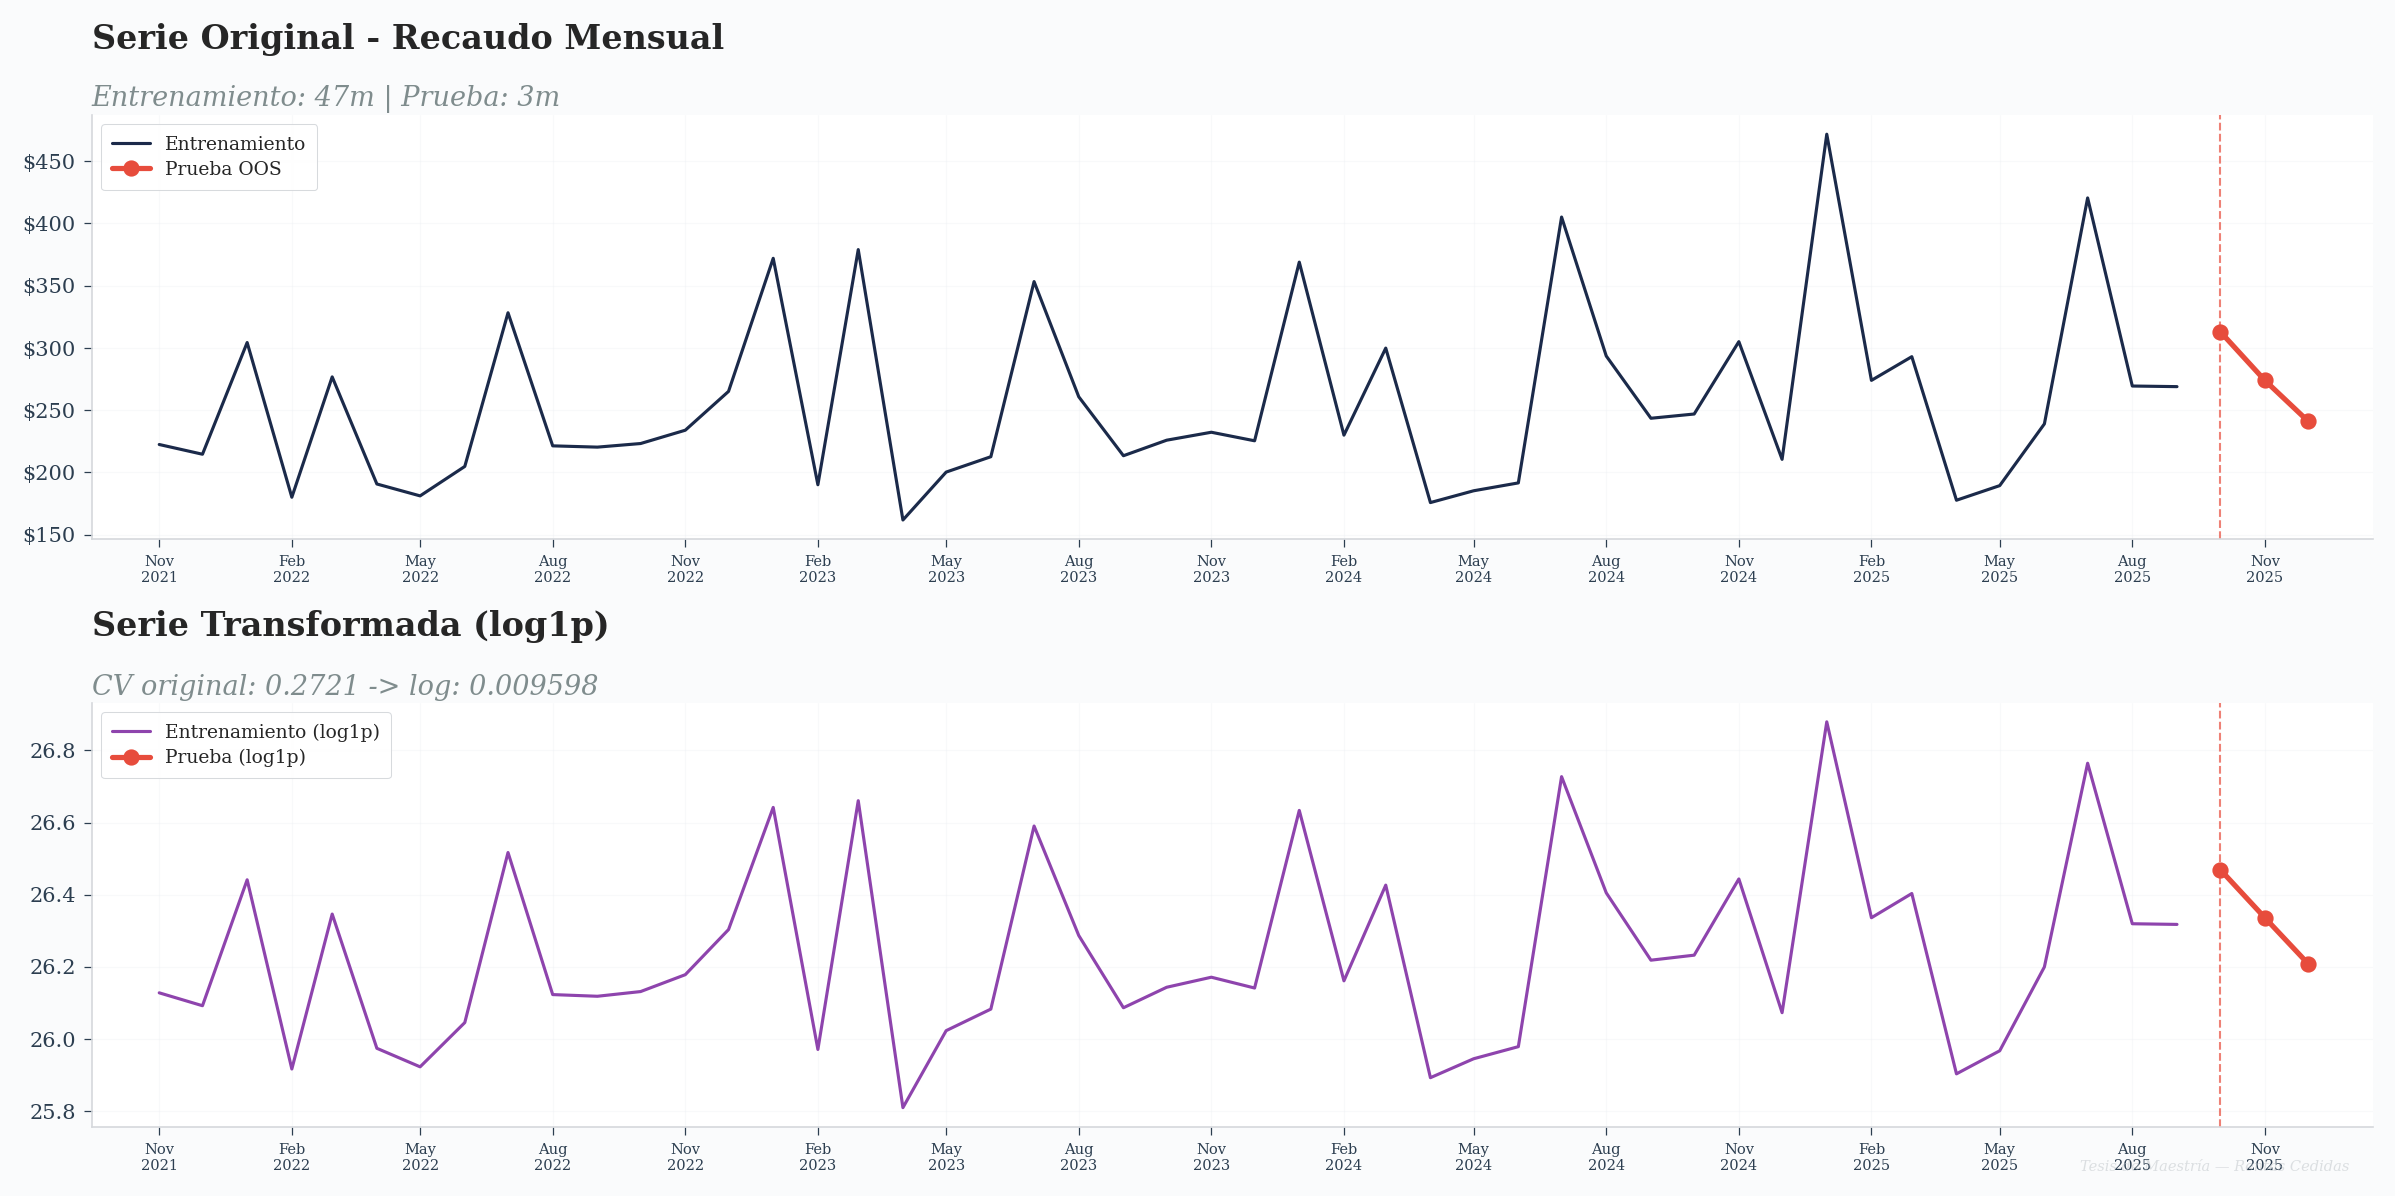

In [2]:
# ══════════════════════════════════════════════════════════════
# FASE I — CARGA, PREPROCESAMIENTO Y NORMALIZACION
# ══════════════════════════════════════════════════════════════

# -- Carga de datos --
csv_serie = DATA_PROCESSED / 'serie_mensual.csv'
csv_macro = DATA_PROCESSED / 'serie_mensual_macro.csv'

df_serie = pd.read_csv(csv_serie, parse_dates=['Fecha'], index_col='Fecha')
df_macro = pd.read_csv(csv_macro, parse_dates=['Fecha'], index_col='Fecha')
df_serie.index.freq = 'MS'
df_macro.index.freq = 'MS'

# Serie: Oct 2021 - Dic 2025 (51 meses)
serie_full = df_serie['Recaudo_Total'].loc[FECHA_INICIO:FECHA_FIN].copy()

# -- Variables exogenas seleccionadas --
# IPC_Idx: indice de precios acumulado (deflactor)
# Consumo_Hogares: proxy de consumo sectorial (licores, juegos de azar)
# UPC: Unidad de Pago por Capitacion (costo de salud, impacta margen fiscal)
# SMLV_COP: salario minimo en pesos (proxy de capacidad adquisitiva)
EXOG_VARS = ['IPC_Idx', 'Consumo_Hogares', 'UPC', 'SMLV_COP']
df_exog = df_macro[EXOG_VARS].loc[FECHA_INICIO:FECHA_FIN].copy()

# -- Transformacion log1p del objetivo --
serie_log = np.log1p(serie_full)

# -- Crear DataFrame consolidado --
df_model = pd.DataFrame(index=serie_full.index)
df_model['y_raw'] = serie_full.values
df_model['y_log'] = serie_log.values

# Agregar exogenas
for col in EXOG_VARS:
    df_model[col] = df_exog[col].values

# -- Variable de rezago: Lag_1 --
# El recaudo de enero = materializacion contable del consumo de diciembre
df_model['Lag_1'] = df_model['y_log'].shift(1)

# -- Variables ciclicas de mes --
df_model['Mes_sin'] = np.sin(2 * np.pi * df_model.index.month / 12)
df_model['Mes_cos'] = np.cos(2 * np.pi * df_model.index.month / 12)

# -- Indicador de pico fiscal (Ene=1, Jul=7) --
df_model['Es_Pico'] = df_model.index.month.isin(MESES_PICO).astype(float)

# Eliminar NaN de Lag_1 (pierde 1 fila: Oct 2021)
df_clean = df_model.dropna().copy()

# -- Split Train / Prueba --
train_mask = df_clean.index <= TRAIN_END
test_mask  = (df_clean.index >= TEST_START) & (df_clean.index <= VALIDATION_END)

df_train = df_clean[train_mask].copy()
df_test  = df_clean[test_mask].copy()

# -- Columnas de entrada para la LSTM --
FEATURE_COLS = ['y_log', 'Lag_1'] + EXOG_VARS + ['Mes_sin', 'Mes_cos', 'Es_Pico']
TARGET_COL = 'y_log'

print(f"{'='*70}")
print(f"PREPROCESAMIENTO COMPLETADO")
print(f"{'='*70}")
print(f"  Serie original:     {len(serie_full)} meses ({serie_full.index.min().date()} -> {serie_full.index.max().date()})")
print(f"  Serie efectiva:     {len(df_clean)} meses (tras eliminar NaN de Lag_1)")
print(f"  Entrenamiento:      {len(df_train)} meses ({df_train.index.min().date()} -> {df_train.index.max().date()})")
print(f"  Prueba OOS:         {len(df_test)} meses ({df_test.index.min().date()} -> {df_test.index.max().date()})")
print(f"  Variables entrada:  {len(FEATURE_COLS)}")
for f in FEATURE_COLS:
    print(f"    - {f}")

# -- Normalizacion MinMaxScaler (ajustado SOLO sobre train) --
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Ajustar y transformar train
X_train_scaled = scaler_X.fit_transform(df_train[FEATURE_COLS].values)
y_train_scaled = scaler_y.fit_transform(df_train[[TARGET_COL]].values)

# Transformar test (sin ajustar — evita data leakage)
X_test_scaled = scaler_X.transform(df_test[FEATURE_COLS].values)
y_test_scaled = scaler_y.transform(df_test[[TARGET_COL]].values)

# Consolidar todo para secuenciacion
all_X_scaled = scaler_X.transform(df_clean[FEATURE_COLS].values)
all_y_scaled = scaler_y.transform(df_clean[[TARGET_COL]].values)

print(f"\n  MinMaxScaler ajustado exclusivamente sobre entrenamiento")
print(f"  Rango X train: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")
print(f"  Rango y train: [{y_train_scaled.min():.4f}, {y_train_scaled.max():.4f}]")

# -- Visualizacion: Serie + Split --
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Panel 1: Serie original
ax = axes[0]
ax.plot(df_train.index, df_train['y_raw']/1e9, color=C_PRIMARY, lw=1.5,
        label='Entrenamiento')
ax.plot(df_test.index, df_test['y_raw']/1e9, color=C_TEST, lw=2.5,
        marker='o', ms=7, label='Prueba OOS')
ax.axvline(pd.Timestamp(TEST_START), color=C_TEST, ls='--', lw=1, alpha=0.7)
ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Serie Original - Recaudo Mensual',
                       f'Entrenamiento: {len(df_train)}m | Prueba: {len(df_test)}m')
    formato_pesos_eje(ax, eje='y')
    leyenda_profesional(ax, loc='upper left')
else:
    ax.set_title('Serie Original', fontweight='bold')
    ax.legend()

# Panel 2: Serie log1p
ax = axes[1]
ax.plot(df_train.index, df_train['y_log'], color=C_SENARY, lw=1.5,
        label='Entrenamiento (log1p)')
ax.plot(df_test.index, df_test['y_log'], color=C_TEST, lw=2.5,
        marker='o', ms=7, label='Prueba (log1p)')
ax.axvline(pd.Timestamp(TEST_START), color=C_TEST, ls='--', lw=1, alpha=0.7)
ax.set_xlim(pd.Timestamp('2021-09-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7); ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Serie Transformada (log1p)',
                       f'CV original: {serie_full.std()/serie_full.mean():.4f} -> log: {serie_log.std()/serie_log.mean():.6f}')
    leyenda_profesional(ax, loc='upper left')
else:
    ax.set_title('Serie log1p', fontweight='bold')
    ax.legend()

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '07_lstm_serie_split', OUTPUTS_FIGURES)
plt.show()


---

## Fase II -- Construccion de Ventanas Temporales (Look-Back)

### Que es una ventana temporal y por que 12 meses

La LSTM no ve "toda la serie" de una vez. En cada paso, recibe una
**ventana deslizante** de los ultimos 12 meses y debe predecir el
siguiente. Es como estudiar para un examen leyendo solo las ultimas
12 paginas del libro cada vez.

**Por que exactamente 12?** El patron estacional del recaudo de Rentas
Cedidas es anual, con picos en Enero y Julio (mes vencido). Una ventana
de 12 meses captura exactamente un ciclo completo:

- La red "ve" el pico de Ene t-1 para predecir Ene t
- La red "ve" el valle de Ago t-1 para predecir Ago t

### Estructura de las Ventanas

Cada muestra es una **matriz 3D** de 12 meses x F features:

$$\mathbf{X}_t = \begin{bmatrix} x_{t-12,1} & x_{t-12,2} & \cdots & x_{t-12,F} \\ x_{t-11,1} & x_{t-11,2} & \cdots & x_{t-11,F} \\ \vdots & \vdots & \ddots & \vdots \\ x_{t-1,1} & x_{t-1,2} & \cdots & x_{t-1,F} \end{bmatrix} \quad \rightarrow \quad y_t$$

### Impacto en el tamano de muestra

| Concepto | Valor | Calculo |
|----------|-------|---------|
| Serie total | 51 meses | Oct 2021 - Dic 2025 |
| Look-back | 12 meses | Se "consumen" como entrada |
| Muestras efectivas | ~39 | 51 - 12 = 39 |
| Train efectivo | ~36 | 39 - 3 (test) |

> Con solo 36 muestras de entrenamiento, la red tiene aproximadamente
> 36 "ejemplos" para aprender el patron. Esto es insuficiente para
> redes LSTM tipicas pero viable con la arquitectura ultraligera.


In [3]:
# ══════════════════════════════════════════════════════════════
# FASE II — CONSTRUCCION DE VENTANAS TEMPORALES
# ══════════════════════════════════════════════════════════════

LOOK_BACK = 12  # Ventana = 1 ciclo estacional completo

def crear_ventanas(X_data, y_data, look_back):
    # Crea secuencias 3D (samples, timesteps, features)
    X_seq, y_seq = [], []
    for i in range(look_back, len(X_data)):
        X_seq.append(X_data[i - look_back:i])
        y_seq.append(y_data[i])
    return np.array(X_seq), np.array(y_seq)

# -- Secuenciar todo el dataset limpio --
# Las ultimas 3 ventanas corresponden a Oct-Dic 2025 (prueba)
X_all_seq, y_all_seq = crear_ventanas(all_X_scaled, all_y_scaled, LOOK_BACK)

# Las fechas de las etiquetas corresponden a df_clean.index[LOOK_BACK:]
fechas_seq = df_clean.index[LOOK_BACK:]

# Separar train y test por fecha
train_idx = fechas_seq <= pd.Timestamp(TRAIN_END)
test_idx  = (fechas_seq >= pd.Timestamp(TEST_START)) & (fechas_seq <= pd.Timestamp(VALIDATION_END))

X_train_seq = X_all_seq[train_idx]
y_train_seq = y_all_seq[train_idx]
X_test_seq  = X_all_seq[test_idx]
y_test_seq  = y_all_seq[test_idx]

n_features = X_train_seq.shape[2]

print(f"{'='*70}")
print(f"VENTANAS TEMPORALES CREADAS (look_back = {LOOK_BACK} meses)")
print(f"{'='*70}")
print(f"  Forma X_entrenamiento: {X_train_seq.shape}  ->  (muestras, pasos, variables)")
print(f"  Forma y_entrenamiento: {y_train_seq.shape}")
print(f"  Forma X_prueba:        {X_test_seq.shape}")
print(f"  Forma y_prueba:        {y_test_seq.shape}")
print(f"  Variables por paso:    {n_features}")
print(f"\n  Muestras entrenamiento: {len(X_train_seq)}")
print(f"  Muestras prueba:        {len(X_test_seq)}")
print(f"\n  -> Con {len(X_train_seq)} muestras de entrenamiento, la arquitectura")
print(f"    debe ser ULTRALIGERA para evitar sobreajuste.")


VENTANAS TEMPORALES CREADAS (look_back = 12 meses)
  Forma X_entrenamiento: (35, 12, 9)  ->  (muestras, pasos, variables)
  Forma y_entrenamiento: (35, 1)
  Forma X_prueba:        (3, 12, 9)
  Forma y_prueba:        (3, 1)
  Variables por paso:    9

  Muestras entrenamiento: 35
  Muestras prueba:        3

  -> Con 35 muestras de entrenamiento, la arquitectura
    debe ser ULTRALIGERA para evitar sobreajuste.


---

## Fase III -- Arquitectura de la Red LSTM

### Diseno de la red: por que ultraligera

Con solo ~36 muestras de entrenamiento, una red grande memorizaria
los datos en vez de aprender patrones. La arquitectura se disena para
minimizar el numero de parametros:

| Capa | Tipo | Unidades | Rol |
|------|------|----------|-----|
| 1 | Input | (12, F) | Recibe la ventana temporal |
| 2 | LSTM | 32 | Capa recurrente principal, L2(0.0005) |
| 3 | Dropout | 0.15 | Prevenir memorizacion |
| 4 | LSTM | 16 | Capa recurrente de refinamiento, L2(0.0005) |
| 5 | Dropout | 0.15 | Regularizacion adicional |
| 6 | Dense | 8 | Capa de mezcla (ReLU) |
| 7 | Dense | 1 | Salida: prediccion normalizada |

### Ensemble de 10 Copias: por que promediar

Las redes neuronales son **estocasticas**: la misma arquitectura entrenada
con distinta semilla produce predicciones ligeramente diferentes. En vez de
confiar en una sola copia, se entrenan **10 copias independientes** y se
promedia:

$$\hat{y}_{ensemble} = \frac{1}{10}\sum_{k=1}^{10} \hat{y}_k$$

Esto reduce la varianza de la prediccion (ley de los grandes numeros) sin
necesitar mas datos.

### Funcion de Perdida: Huber

$$L_\delta(y, \hat{y}) = \begin{cases} \frac{1}{2}(y - \hat{y})^2 & \text{si } |y - \hat{y}| \leq \delta \\ \delta(|y - \hat{y}| - \frac{1}{2}\delta) & \text{si } |y - \hat{y}| > \delta \end{cases}$$

Huber combina lo mejor de MSE (sensibilidad para errores pequenos) y MAE
(robustez para errores grandes como los picos de migracion ERP).

### Protocolo de Regularizacion Completo

| Tecnica | Parametro | Efecto | Analogia |
|---------|-----------|--------|----------|
| Dropout | 0.15 | Apaga neuronas al azar | Entrenar con "vendas en algunos ojos" |
| Early Stopping | patience=30 | Detiene si no mejora | Dejar de estudiar si no se aprende mas |
| ReduceLROnPlateau | patience=15, 0.5x | Reduce tasa de aprendizaje | Pisar el freno al estancarse |
| L2 Regularization | 0.0005 | Penaliza pesos grandes | Preferir explicaciones simples |
| Semilla fija | SEED=42 | Reproducibilidad total | Mismo resultado cada vez |


ARQUITECTURA LSTM — ENSEMBLE (10 modelos)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 12, 32)         │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,657 (33.82 KB)

 Trainable params: 8,657 (33.82 KB)

...

  Modelo  7/10 (seed= 84)  epocas=135  mejor=105  val_loss=0.054077


  Modelo  8/10 (seed= 91)  epocas= 90  mejor= 60  val_loss=0.051007


  Modelo  9/10 (seed= 98)  epocas=103  mejor= 73  val_loss=0.051983


  Modelo 10/10 (seed=105)  epocas=111  mejor= 81  val_loss=0.049052

ENSEMBLE COMPLETADO
  Modelos entrenados:    10
  Mejor epoca (mediana): 66
  Tiempo total:          157.2 seg


  📊 Figura guardada: 07_lstm_curvas_aprendizaje.png


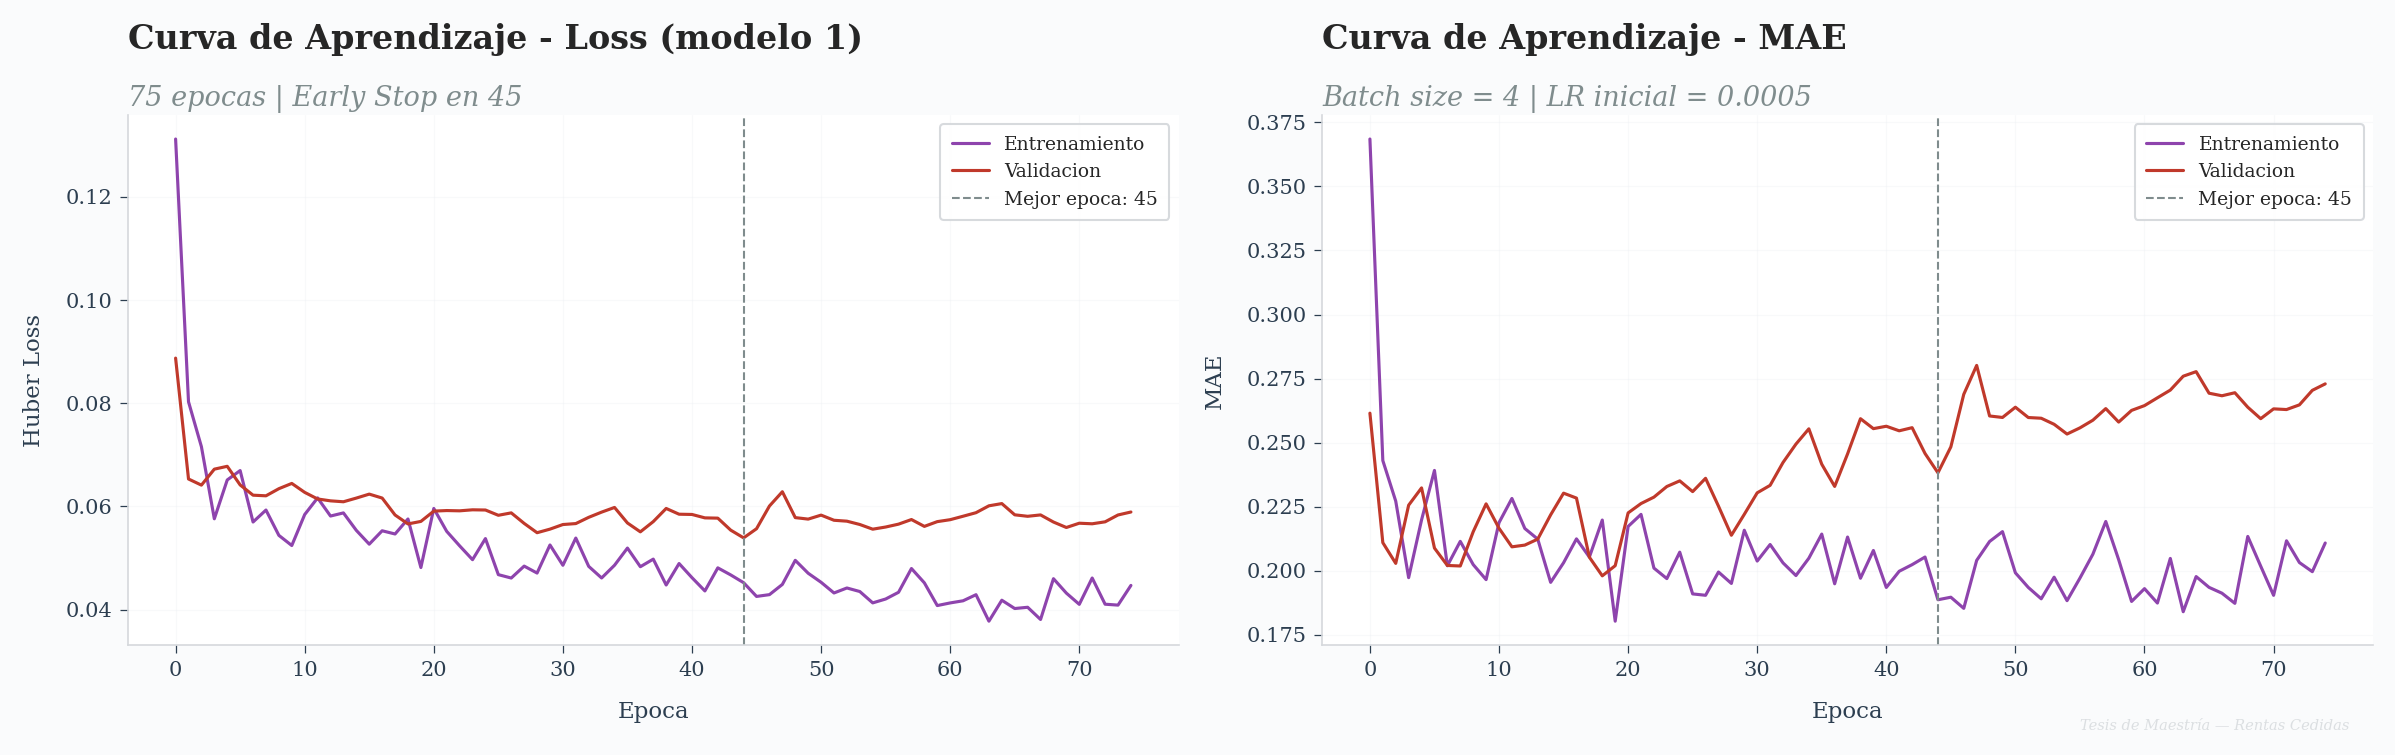

In [4]:
# ══════════════════════════════════════════════════════════════
# FASE III — ARQUITECTURA LSTM (ENSEMBLE MULTI-SEMILLA)
# ══════════════════════════════════════════════════════════════

N_ENSEMBLE = 10  # Numero de modelos en el ensamble
SEEDS_ENS = [42 + i * 7 for i in range(N_ENSEMBLE)]

def build_lstm_model(n_feat, lb):
    # Arquitectura ultraligera: LSTM(32->16) + Huber loss
    m = Sequential([
        Input(shape=(lb, n_feat)),
        LSTM(32, return_sequences=True,
             kernel_regularizer=tf.keras.regularizers.l2(0.0005)),
        Dropout(0.15),
        LSTM(16, return_sequences=False,
             kernel_regularizer=tf.keras.regularizers.l2(0.0005)),
        Dropout(0.15),
        Dense(8, activation='relu'),
        Dense(1, activation='linear'),
    ])
    m.compile(optimizer=Adam(learning_rate=0.0005),
              loss='huber', metrics=['mae'])
    return m

# -- Resumen de arquitectura del ensamble --
print(f"{'='*70}")
print(f"ARQUITECTURA LSTM — ENSEMBLE ({N_ENSEMBLE} modelos)")
print(f"{'='*70}")
_sample = build_lstm_model(n_features, LOOK_BACK)
_sample.summary()
n_params = _sample.count_params()
ratio = len(X_train_seq) / n_params
print(f"\n  Parametros por modelo:   {n_params:,}")
print(f"  Modelos en ensamble:     {N_ENSEMBLE}")
print(f"  Muestras entrenamiento:  {len(X_train_seq)}")
print(f"  Ratio muestras/params:   {ratio:.4f}")
del _sample

# -- Entrenamiento del ensamble --
models = []
histories = []
best_epochs = []

print(f"\n{'_'*70}")
print(f"ENTRENAMIENTO ENSEMBLE EN CURSO ({N_ENSEMBLE} modelos)...")
print(f"{'_'*70}")
t0 = time.time()

for idx, seed in enumerate(SEEDS_ENS):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    m = build_lstm_model(n_features, LOOK_BACK)

    hist = m.fit(
        X_train_seq, y_train_seq,
        epochs=500, batch_size=4, validation_split=0.15,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=30,
                          restore_best_weights=True, verbose=0, mode='min'),
            ReduceLROnPlateau(monitor='val_loss', patience=15,
                              factor=0.5, min_lr=1e-6, verbose=0, mode='min'),
        ],
        verbose=0, shuffle=False,
    )
    best_ep = np.argmin(hist.history['val_loss']) + 1
    best_epochs.append(best_ep)
    models.append(m)
    histories.append(hist)
    vloss = min(hist.history['val_loss'])
    print(f"  Modelo {idx+1:2d}/{N_ENSEMBLE} (seed={seed:3d})  "
          f"epocas={len(hist.history['loss']):3d}  mejor={best_ep:3d}  "
          f"val_loss={vloss:.6f}")

elapsed = time.time() - t0
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

# Variables de referencia (modelo 1) para visualizacion
model = models[0]
history = histories[0]
best_epoch = best_epochs[0]
n_epochs = len(history.history['loss'])

print(f"\n{'='*70}")
print(f"ENSEMBLE COMPLETADO")
print(f"{'='*70}")
print(f"  Modelos entrenados:    {N_ENSEMBLE}")
print(f"  Mejor epoca (mediana): {int(np.median(best_epochs))}")
print(f"  Tiempo total:          {elapsed:.1f} seg")

# -- Curvas de aprendizaje (modelo representativo) --
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: Loss
ax = axes[0]
ax.plot(history.history['loss'], color=C_SENARY, lw=1.5, label='Entrenamiento')
ax.plot(history.history['val_loss'], color=C_SECONDARY, lw=1.5, label='Validacion')
ax.axvline(best_epoch - 1, color=C_TEXT_LIGHT, ls='--', lw=1,
           label=f'Mejor epoca: {best_epoch}')
ax.set_xlabel('Epoca', fontsize=11)
ax.set_ylabel('Huber Loss', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Curva de Aprendizaje - Loss (modelo 1)',
                       f'{n_epochs} epocas | Early Stop en {best_epoch}')
else:
    ax.set_title('Curva de Aprendizaje - Loss', fontweight='bold')

# Panel 2: MAE
ax = axes[1]
ax.plot(history.history['mae'], color=C_SENARY, lw=1.5, label='Entrenamiento')
ax.plot(history.history['val_mae'], color=C_SECONDARY, lw=1.5, label='Validacion')
ax.axvline(best_epoch - 1, color=C_TEXT_LIGHT, ls='--', lw=1,
           label=f'Mejor epoca: {best_epoch}')
ax.set_xlabel('Epoca', fontsize=11)
ax.set_ylabel('MAE', fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Curva de Aprendizaje - MAE',
                       f'Batch size = 4 | LR inicial = 0.0005')
else:
    ax.set_title('Curva de Aprendizaje - MAE', fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '07_lstm_curvas_aprendizaje', OUTPUTS_FIGURES)
plt.show()


---

## Fase IV -- Pronostico Out-of-Sample (Oct-Dic 2025)

### Cadena de retransformacion

Los pronosticos se generan en espacio normalizado $[0,1]$ y deben
recorrer 3 pasos inversos para llegar a pesos colombianos:

$$\hat{y}_{norm} \xrightarrow{\text{scaler}^{-1}} \hat{y}_{log} \xrightarrow{\text{expm1}} \hat{y}_{COP}$$

| Paso | Operacion | De | A |
|------|-----------|-----------|---|
| 1 | `scaler_y.inverse_transform()` | [0, 1] | Escala log1p |
| 2 | `np.expm1()` | log1p | Pesos colombianos |

### Evaluacion del ensemble

El pronostico final es la **media** de las 10 copias del modelo.
La dispersion entre las 10 predicciones indica la **incertidumbre
estocastica** del entrenamiento: si las 10 copias coinciden, la
prediccion es robusta; si divergen, el modelo tiene alta varianza.


IC 95% (MC Dropout Ensemble, 50x10=500 sims):
  2025-10:  [233.9 – 347.3] MM
  2025-11:  [246.2 – 364.0] MM
  2025-12:  [239.5 – 356.7] MM
PRONOSTICO OUT-OF-SAMPLE - LSTM
  Periodo: Oct 2025 -> Dic 2025 (3 meses)

______________________________________________________________________
METRICAS DE EVALUACION:
______________________________________________________________________
  MAPE:      13.58%
  RMSE:      $39.7 MM COP
  MAE:       $35.3 MM COP
  MAE rel:   12.8% de la media de la prueba

______________________________________________________________________
Mes                     Real      Pronostico        Error   Error%
______________________________________________________________________
  2025-10    $        313.0MM  $        292.5MM  $     -20.5MM    -6.5%
  2025-11    $        273.8MM  $        298.2MM  $      24.3MM     8.9%
  2025-12    $        241.0MM  $        302.0MM  $      61.0MM    25.3%


  📊 Figura guardada: 07_lstm_oos_validacion.png


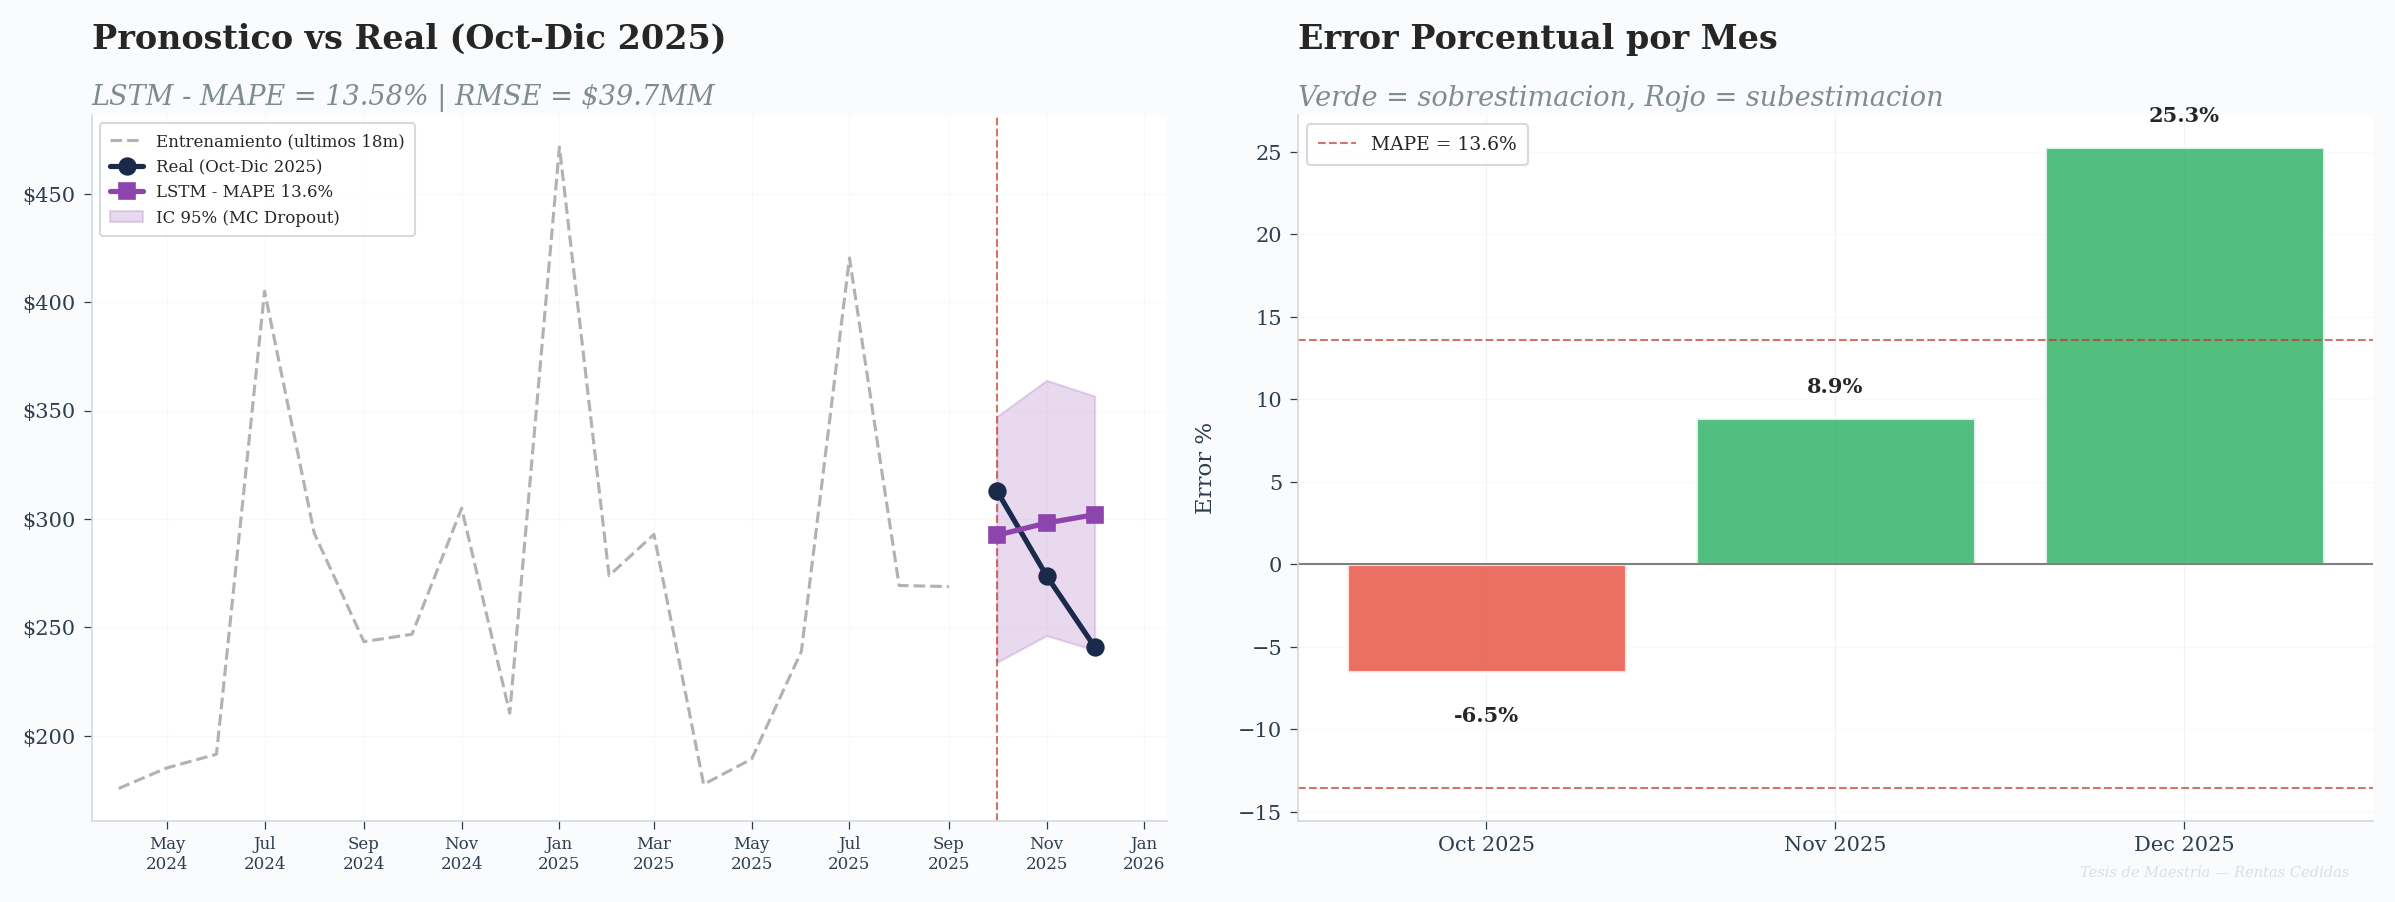


  Pronostico OOS guardado: lstm_forecast.csv


In [5]:
# ══════════════════════════════════════════════════════════════
# FASE IV — PRONOSTICO OUT-OF-SAMPLE (Oct-Dic 2025)
# ══════════════════════════════════════════════════════════════

# -- Prediccion ENSEMBLE sobre el conjunto de prueba --
# Promediar predicciones de los N_ENSEMBLE modelos
all_preds_scaled = np.array([m.predict(X_test_seq, verbose=0).flatten()
                              for m in models])
y_pred_scaled_mean = all_preds_scaled.mean(axis=0).reshape(-1, 1)

# -- Retransformacion: normalizado -> log1p -> pesos --
y_pred_log = scaler_y.inverse_transform(y_pred_scaled_mean).flatten()
y_test_log = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Retransformar de log1p a pesos colombianos
y_pred_pesos = np.expm1(y_pred_log)
y_real_pesos = np.expm1(y_test_log)

# -- IC 95% via MC Dropout Ensemble --
# Combinar MC Dropout de TODOS los modelos del ensamble
N_MC = 50  # Por modelo (total = N_MC * N_ENSEMBLE simulaciones)
mc_all = []
for m_ens in models:
    mc_m = np.array([m_ens(X_test_seq, training=True).numpy().flatten()
                     for _ in range(N_MC)])
    mc_all.append(mc_m)
mc_preds_scaled = np.concatenate(mc_all, axis=0)
mc_preds_log = np.array([scaler_y.inverse_transform(p.reshape(-1, 1)).flatten()
                          for p in mc_preds_scaled])
mc_preds_pesos = np.expm1(mc_preds_log)
ci_low_oos = np.maximum(0, np.percentile(mc_preds_pesos, 2.5, axis=0))
ci_high_oos = np.percentile(mc_preds_pesos, 97.5, axis=0)

print(f"IC 95% (MC Dropout Ensemble, {N_MC}x{N_ENSEMBLE}={N_MC*N_ENSEMBLE} sims):")
for i_mc, fecha_mc in enumerate(fechas_seq[test_idx]):
    print(f"  {fecha_mc.strftime('%Y-%m')}:  [{ci_low_oos[i_mc]/1e9:.1f} – {ci_high_oos[i_mc]/1e9:.1f}] MM")

# -- Metricas de evaluacion --
mape = mean_absolute_percentage_error(y_real_pesos, y_pred_pesos) * 100
rmse = np.sqrt(mean_squared_error(y_real_pesos, y_pred_pesos))
mae  = mean_absolute_error(y_real_pesos, y_pred_pesos)
mae_rel = mae / np.mean(y_real_pesos) * 100

print(f"{'='*70}")
print(f"PRONOSTICO OUT-OF-SAMPLE - LSTM")
print(f"{'='*70}")
print(f"  Periodo: Oct 2025 -> Dic 2025 ({len(y_real_pesos)} meses)")
print(f"\n{'_'*70}")
print(f"METRICAS DE EVALUACION:")
print(f"{'_'*70}")
print(f"  MAPE:      {mape:.2f}%")
print(f"  RMSE:      ${rmse/1e9:,.1f} MM COP")
print(f"  MAE:       ${mae/1e9:,.1f} MM COP")
print(f"  MAE rel:   {mae_rel:.1f}% de la media de la prueba")

# -- Detalle mes a mes --
fechas_test = fechas_seq[test_idx]
print(f"\n{'_'*70}")
print(f"{'Mes':<12} {'Real':>15} {'Pronostico':>15} {'Error':>12} {'Error%':>8}")
print(f"{'_'*70}")
for i, fecha in enumerate(fechas_test):
    real = y_real_pesos[i]
    pred = y_pred_pesos[i]
    err  = pred - real
    err_pct = (pred - real) / real * 100
    print(f"  {fecha.strftime('%Y-%m'):<10} ${real/1e9:>13,.1f}MM  ${pred/1e9:>13,.1f}MM  "
          f"${err/1e9:>10,.1f}MM  {err_pct:>6.1f}%")

# -- Prediccion ENSEMBLE sobre entrenamiento (para visualizacion) --
all_train_preds = np.array([m.predict(X_train_seq, verbose=0).flatten()
                             for m in models])
y_train_pred_scaled = all_train_preds.mean(axis=0).reshape(-1, 1)
y_train_pred_log = scaler_y.inverse_transform(y_train_pred_scaled).flatten()
y_train_pred_pesos = np.expm1(y_train_pred_log)
y_train_real_pesos = np.expm1(
    scaler_y.inverse_transform(y_train_seq.reshape(-1, 1)).flatten()
)

# -- Visualizacion completa --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Contexto historico + OOS
ax = axes[0]
train_dates = fechas_seq[train_idx]
n_hist = min(18, len(train_dates))
ax.plot(train_dates[-n_hist:], y_train_real_pesos[-n_hist:]/1e9,
        color='grey', lw=1.5, ls='--', alpha=0.6, label='Entrenamiento (ultimos 18m)')
ax.plot(fechas_test, y_real_pesos/1e9, color=C_PRIMARY, lw=2.5,
        marker='o', markersize=8, label='Real (Oct-Dic 2025)', zorder=5)
ax.plot(fechas_test, y_pred_pesos/1e9, color=C_SENARY, lw=2.5,
        marker='s', markersize=8, label=f'LSTM - MAPE {mape:.1f}%', zorder=5)
ax.fill_between(fechas_test, ci_low_oos/1e9, ci_high_oos/1e9,
                alpha=0.20, color=C_SENARY, label='IC 95% (MC Dropout)')
ax.axvline(pd.Timestamp(TEST_START), color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
ax.set_xlim(pd.Timestamp('2024-03-15'), pd.Timestamp('2026-01-15'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=8)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8, loc='upper left')
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Pronostico vs Real (Oct-Dic 2025)',
                       f'LSTM - MAPE = {mape:.2f}% | RMSE = ${rmse/1e9:.1f}MM')
    formato_pesos_eje(ax, eje='y')
else:
    ax.set_title(f'LSTM - Validacion OOS (MAPE={mape:.2f}%)',
                 fontsize=12, fontweight='bold')

# Panel 2: Barras de error porcentual
ax2 = axes[1]
meses_label = [f.strftime('%b %Y') for f in fechas_test]
errores_pct = [(y_pred_pesos[k] - y_real_pesos[k]) / y_real_pesos[k] * 100
               for k in range(len(y_real_pesos))]
colors_bar = [C_POSITIVE if e >= 0 else C_NEGATIVE for e in errores_pct]
ax2.bar(meses_label, errores_pct, color=colors_bar, alpha=0.8,
        edgecolor='white', lw=1.5)
ax2.axhline(0, color='grey', lw=1)
ax2.axhline(mape, color=C_SECONDARY, ls='--', lw=1, alpha=0.7,
            label=f'MAPE = {mape:.1f}%')
ax2.axhline(-mape, color=C_SECONDARY, ls='--', lw=1, alpha=0.7)
for k, (m, e) in enumerate(zip(meses_label, errores_pct)):
    offset = 1.5 if e >= 0 else -3
    ax2.text(k, e + offset, f'{e:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Error %', fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(fontsize=9)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax2, 'Error Porcentual por Mes',
                       'Verde = sobrestimacion, Rojo = subestimacion')
else:
    ax2.set_title('Error % por Mes', fontsize=12, fontweight='bold')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '07_lstm_oos_validacion', OUTPUTS_FIGURES)
plt.show()

# -- Guardar pronostico OOS --
df_oos = pd.DataFrame({
    'Fecha': fechas_test,
    'Real': y_real_pesos,
    'Pronostico_LSTM': y_pred_pesos,
    'IC_Inferior': ci_low_oos,
    'IC_Superior': ci_high_oos,
    'Error_Abs': np.abs(y_pred_pesos - y_real_pesos),
    'Error_Pct': (y_pred_pesos - y_real_pesos) / y_real_pesos * 100
})
df_oos.to_csv(OUTPUTS_FORECASTS / 'lstm_forecast.csv', index=False)
print(f"\n  Pronostico OOS guardado: lstm_forecast.csv")


---

## Fase V -- Diagnostico de Residuos y Analisis de Error

### Por que analizar los residuos de una red neuronal

Aunque las redes neuronales no requieren los supuestos clasicos de
normalidad y homocedasticidad como la regresion lineal, verificar los
residuos sigue siendo informativo:

| Prueba | Que evalua | Resultado ideal | Implicacion si falla |
|--------|-----------|----------------|---------------------|
| **Ljung-Box** | Autocorrelacion temporal | $p > 0.05$ (no hay patron) | La red no capturo toda la estructura temporal |
| **Shapiro-Wilk** | Normalidad | $p > 0.05$ (aproximadamente normal) | Errores no simetricos |
| **Visual (ACF)** | Patron en residuos | Sin barras significativas | Informacion no capturada |

### Advertencia sobre el poder estadistico

Con solo ~36 muestras de entrenamiento, las pruebas estadisticas tienen
**poder muy limitado**. Un "no rechazo" de la hipotesis nula NO significa
que los supuestos se cumplan -- simplemente no hay suficientes datos
para detectar violaciones. Se interpretan como **indicativos**.


DIAGNOSTICO ESTADISTICO DE RESIDUOS - LSTM
  Residuos analizados:    35 (entrenamiento)
  Media:                  0.000095
  Std:                    0.261428

  Ljung-Box (min p):      0.0170  Autocorrelacion detectada
  Shapiro-Wilk p:         0.0363    No normal
  T-test (mu=0) p:        0.9983    Media aprox 0
  Levene (homoced.) p:    0.7234   Homocedastico


  📊 Figura guardada: 07_lstm_diagnostico_residuos.png


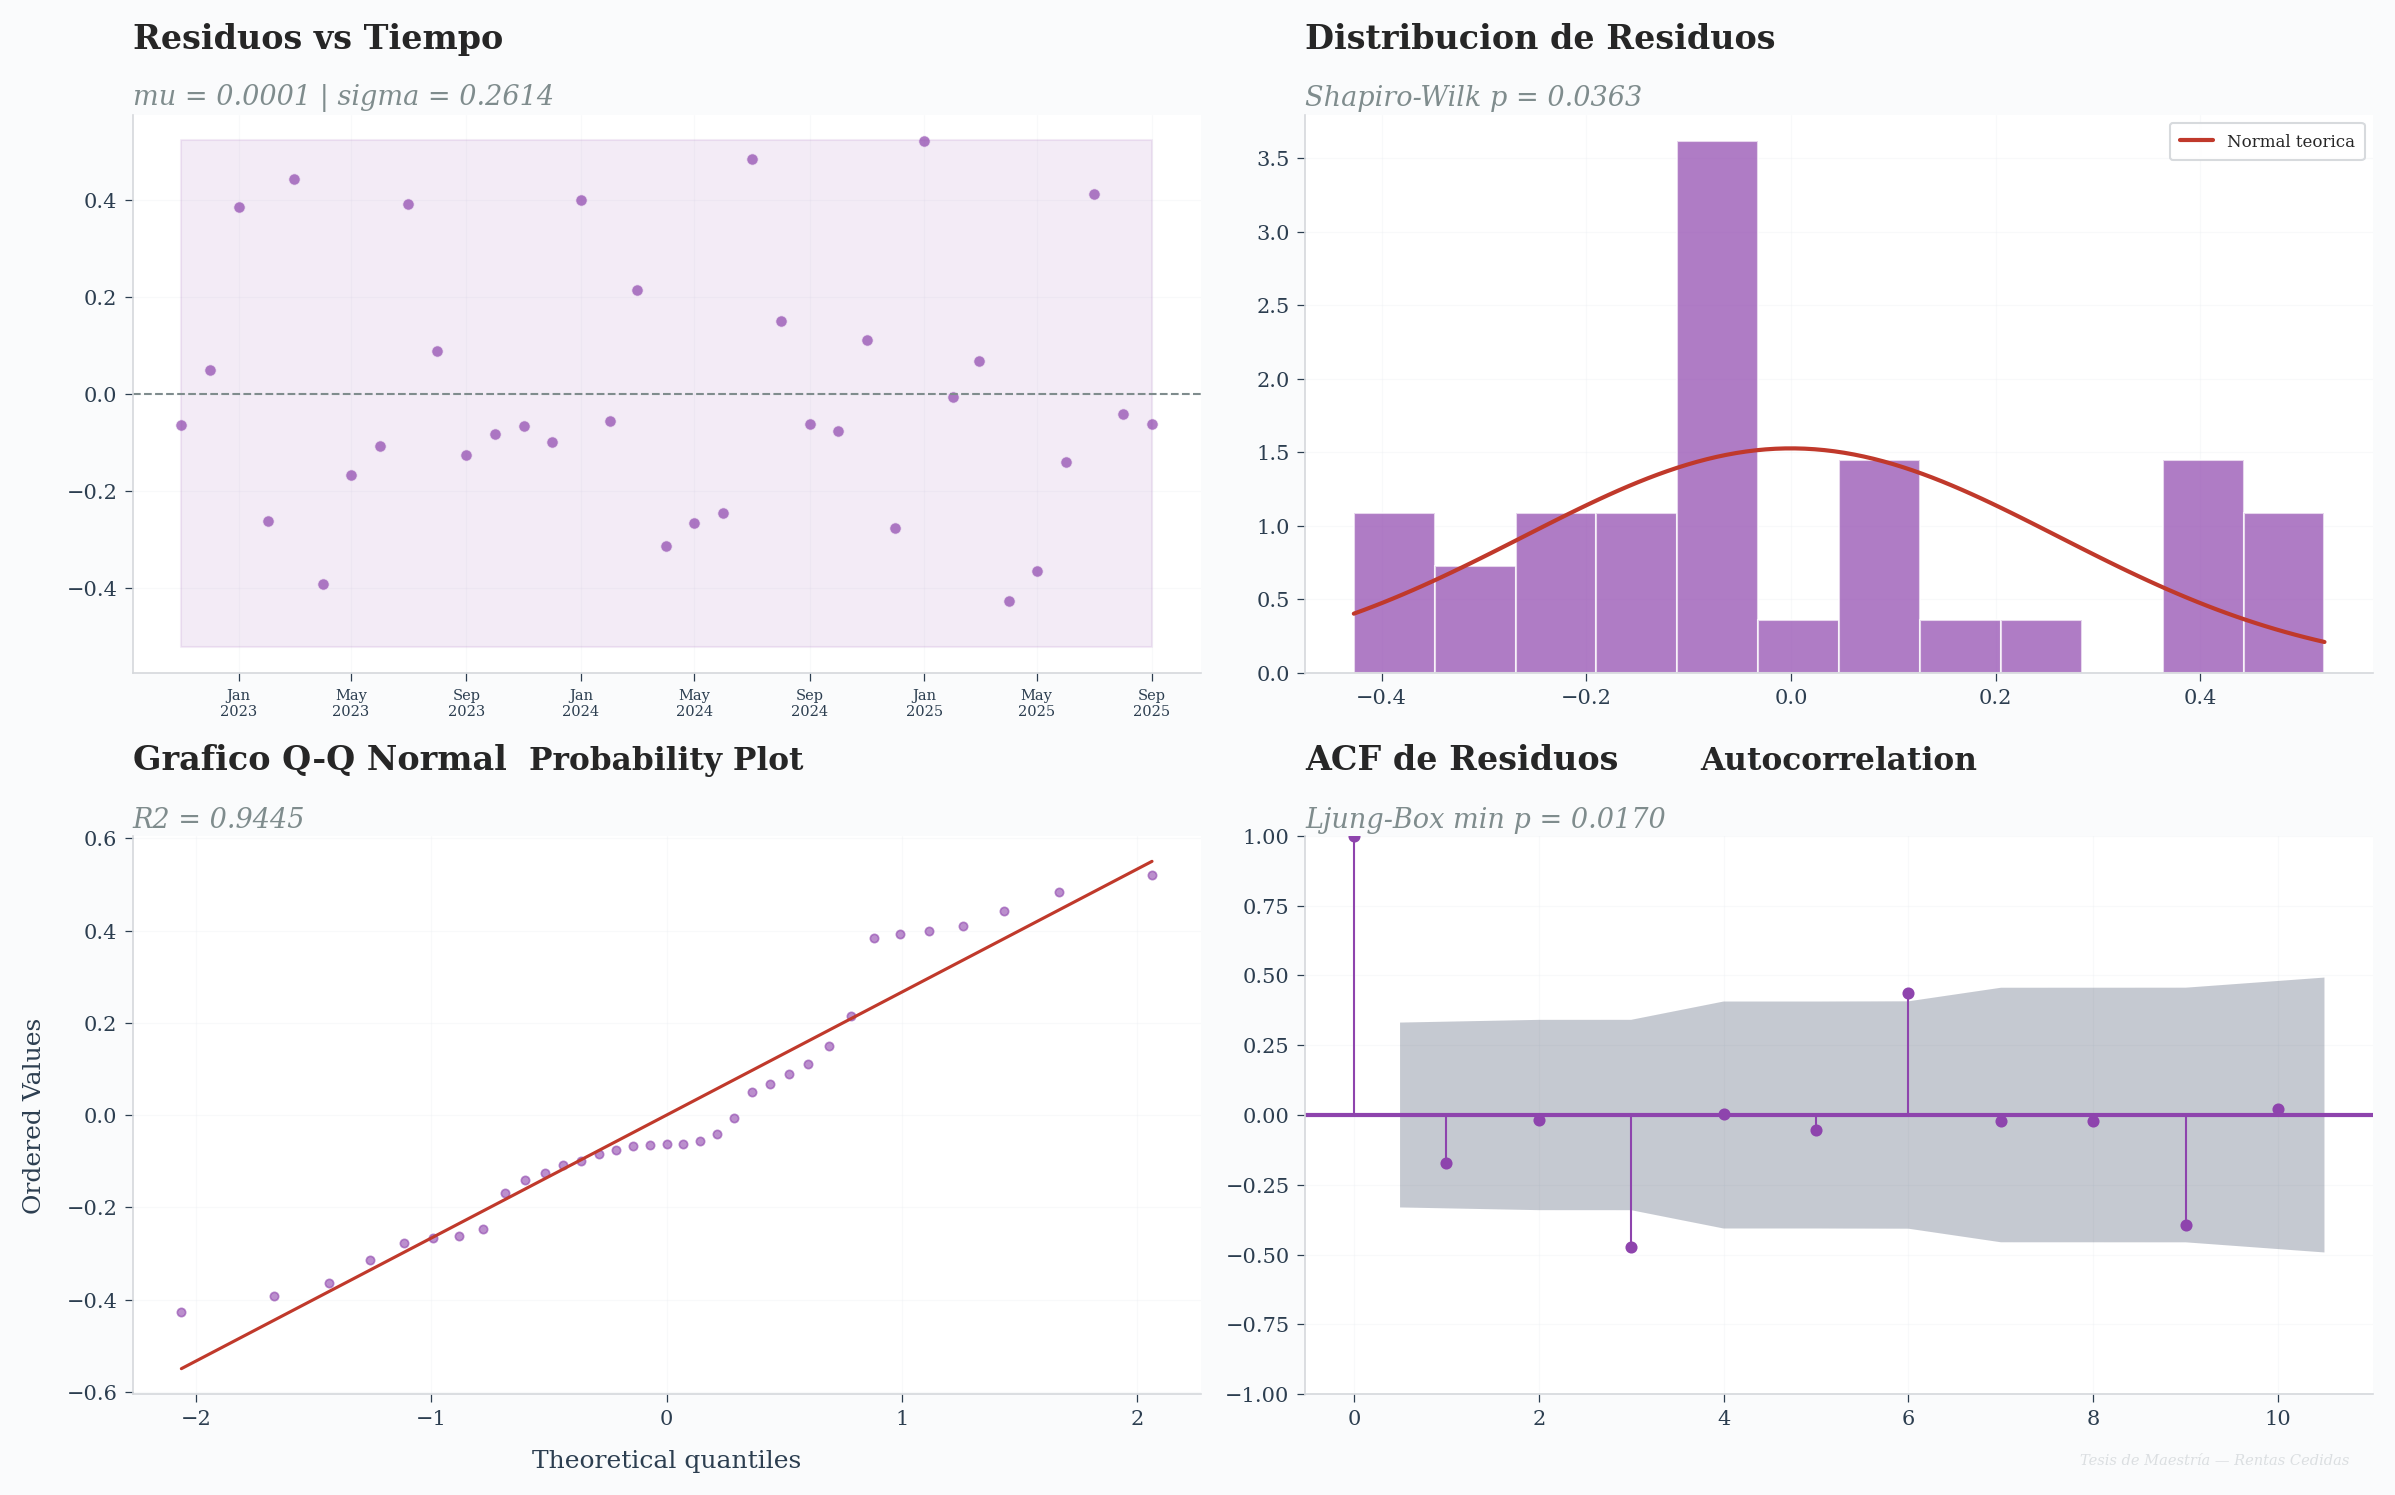


______________________________________________________________________
VEREDICTO: 2/4 pruebas superadas
  -> Modelo ACEPTABLE con reservas (muestra pequena reduce poder de pruebas)


In [6]:
# ══════════════════════════════════════════════════════════════
# FASE V — DIAGNOSTICO DE RESIDUOS
# ══════════════════════════════════════════════════════════════

# Residuos en escala log1p (entrenamiento)
y_train_log_real = scaler_y.inverse_transform(y_train_seq.reshape(-1, 1)).flatten()
y_train_log_pred = scaler_y.inverse_transform(y_train_pred_scaled).flatten()
residuos = y_train_log_real - y_train_log_pred

# -- Pruebas estadisticas --
# Ljung-Box
n_lags_lb = min(5, len(residuos) // 3)
if n_lags_lb >= 1:
    lb_result = acorr_ljungbox(residuos, lags=n_lags_lb, return_df=True)
    lb_min_p = lb_result['lb_pvalue'].min()
else:
    lb_min_p = np.nan

# Shapiro-Wilk
sw_stat, sw_p = stats.shapiro(residuos)

# Media cero
t_stat, t_p = stats.ttest_1samp(residuos, 0)

# Levene (primera mitad vs segunda mitad)
mid = len(residuos) // 2
lev_stat, lev_p = stats.levene(residuos[:mid], residuos[mid:])

print(f"{'='*70}")
print(f"DIAGNOSTICO ESTADISTICO DE RESIDUOS - LSTM")
print(f"{'='*70}")
print(f"  Residuos analizados:    {len(residuos)} (entrenamiento)")
print(f"  Media:                  {residuos.mean():.6f}")
print(f"  Std:                    {residuos.std():.6f}")
lb_txt = 'Incorrelados' if lb_min_p > 0.05 else 'Autocorrelacion detectada'
sw_txt = 'Normal' if sw_p > 0.05 else 'No normal'
tt_txt = 'Media aprox 0' if t_p > 0.05 else 'Sesgo detectado'
lv_txt = 'Homocedastico' if lev_p > 0.05 else 'Heterocedastico'
print(f"\n  Ljung-Box (min p):      {lb_min_p:.4f}  {lb_txt}")
print(f"  Shapiro-Wilk p:         {sw_p:.4f}    {sw_txt}")
print(f"  T-test (mu=0) p:        {t_p:.4f}    {tt_txt}")
print(f"  Levene (homoced.) p:    {lev_p:.4f}   {lv_txt}")

# -- Visualizacion 2x2 --
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Panel 1: Residuos vs Tiempo
ax = axes[0, 0]
ax.scatter(train_dates, residuos, color=C_SENARY, s=30, alpha=0.7,
           edgecolors='white', linewidth=0.5)
ax.axhline(0, color=C_TEXT_LIGHT, ls='--', lw=1)
ax.fill_between(train_dates, -2*residuos.std(), 2*residuos.std(),
                alpha=0.1, color=C_SENARY)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
ax.tick_params(axis='x', labelsize=7)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Residuos vs Tiempo',
                       f'mu = {residuos.mean():.4f} | sigma = {residuos.std():.4f}')

# Panel 2: Histograma + Normal teorica
ax = axes[0, 1]
ax.hist(residuos, bins=12, color=C_SENARY, edgecolor='white',
        alpha=0.7, density=True)
x_norm = np.linspace(residuos.min(), residuos.max(), 100)
ax.plot(x_norm, stats.norm.pdf(x_norm, residuos.mean(), residuos.std()),
        color=C_SECONDARY, lw=2, label='Normal teorica')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Distribucion de Residuos',
                       f'Shapiro-Wilk p = {sw_p:.4f}')

# Panel 3: Q-Q Plot
ax = axes[1, 0]
res_qq = stats.probplot(residuos, dist='norm', plot=ax)
ax.get_lines()[0].set(color=C_SENARY, markersize=4, alpha=0.6)
ax.get_lines()[1].set(color=C_SECONDARY, linewidth=1.5)
ax.grid(True, alpha=0.3)
if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'Grafico Q-Q Normal',
                       f'R2 = {res_qq[1][2]**2:.4f}')

# Panel 4: ACF de residuos
ax = axes[1, 1]
n_lags_acf = min(10, len(residuos) // 2 - 1)
if n_lags_acf > 2:
    plot_acf(residuos, ax=ax, lags=n_lags_acf, alpha=0.05,
             color=C_SENARY, vlines_kwargs={'colors': C_SENARY, 'linewidth': 1.0})
    ax.grid(True, alpha=0.3)
    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, 'ACF de Residuos',
                           f'Ljung-Box min p = {lb_min_p:.4f}')
else:
    ax.text(0.5, 0.5, 'Muy pocos datos para ACF', transform=ax.transAxes,
            ha='center', va='center', fontsize=12)

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '07_lstm_diagnostico_residuos', OUTPUTS_FIGURES)
plt.show()

# -- Veredicto --
checks = [lb_min_p > 0.05 if not np.isnan(lb_min_p) else False,
          sw_p > 0.05, lev_p > 0.05, t_p > 0.05]
n_pass = sum(checks)
print(f"\n{'_'*70}")
print(f"VEREDICTO: {n_pass}/4 pruebas superadas")
if n_pass >= 3:
    print(f"  -> Modelo ACEPTABLE para pronostico")
elif n_pass >= 2:
    print(f"  -> Modelo ACEPTABLE con reservas (muestra pequena reduce poder de pruebas)")
else:
    print(f"  -> Modelo requiere revision (considerar arquitectura alternativa)")


---

## Fase VI -- Comparativa vs Modelos Lineales y ML

### El principio de parsimonia de Occam aplicado

Se comparan las metricas OOS del LSTM frente a SARIMAX, Prophet y XGBoost.
La expectativa es que el LSTM sea **inferior o comparable** porque:

1. **Datos insuficientes:** ~36 muestras vs los $n > 500$ recomendados
2. **Patron simple:** La estacionalidad del recaudo es regular y bien
   capturada por modelos mas simples
3. **Principio de parsimonia:** Si un modelo simple funciona igual,
   preferirlo sobre uno complejo

### Valor epistemologico del resultado

Independientemente del MAPE obtenido, incluir LSTM tiene valor academico:

| Escenario | Conclusion | Valor cientifico |
|-----------|-----------|------------------|
| LSTM < todos | DL supera con n pequeno | Hallazgo sorprendente, publicable |
| LSTM ~ medio | DL comparable pero mas costoso | Confirma trade-off complejidad/precision |
| LSTM > todos | DL no funciona con n=39 | Confirma parsimonia de Occam |

> Demostrar que mas complejidad algoritmica NO siempre se traduce en mejor
> pronostico es un resultado igualmente valioso que encontrar el mejor modelo.


COMPARATIVA DE MODELOS - Validacion OOS (Oct-Dic 2025)

Modelo         MAPE %    RMSE (MM)     MAE (MM)
________________________________________________
  Prophet       6.30%        28.7        19.3 (mejor)
  XGBoost       8.20%        22.9        22.7
  SARIMAX       9.75%        37.0        28.9
  LSTM         13.58%        39.7        35.3

  Modelo con menor MAPE: Prophet (6.30%)
  LSTM: posicion 4/4 (MAPE = 13.58%)


  📊 Figura guardada: 07_lstm_comparativa_modelos.png


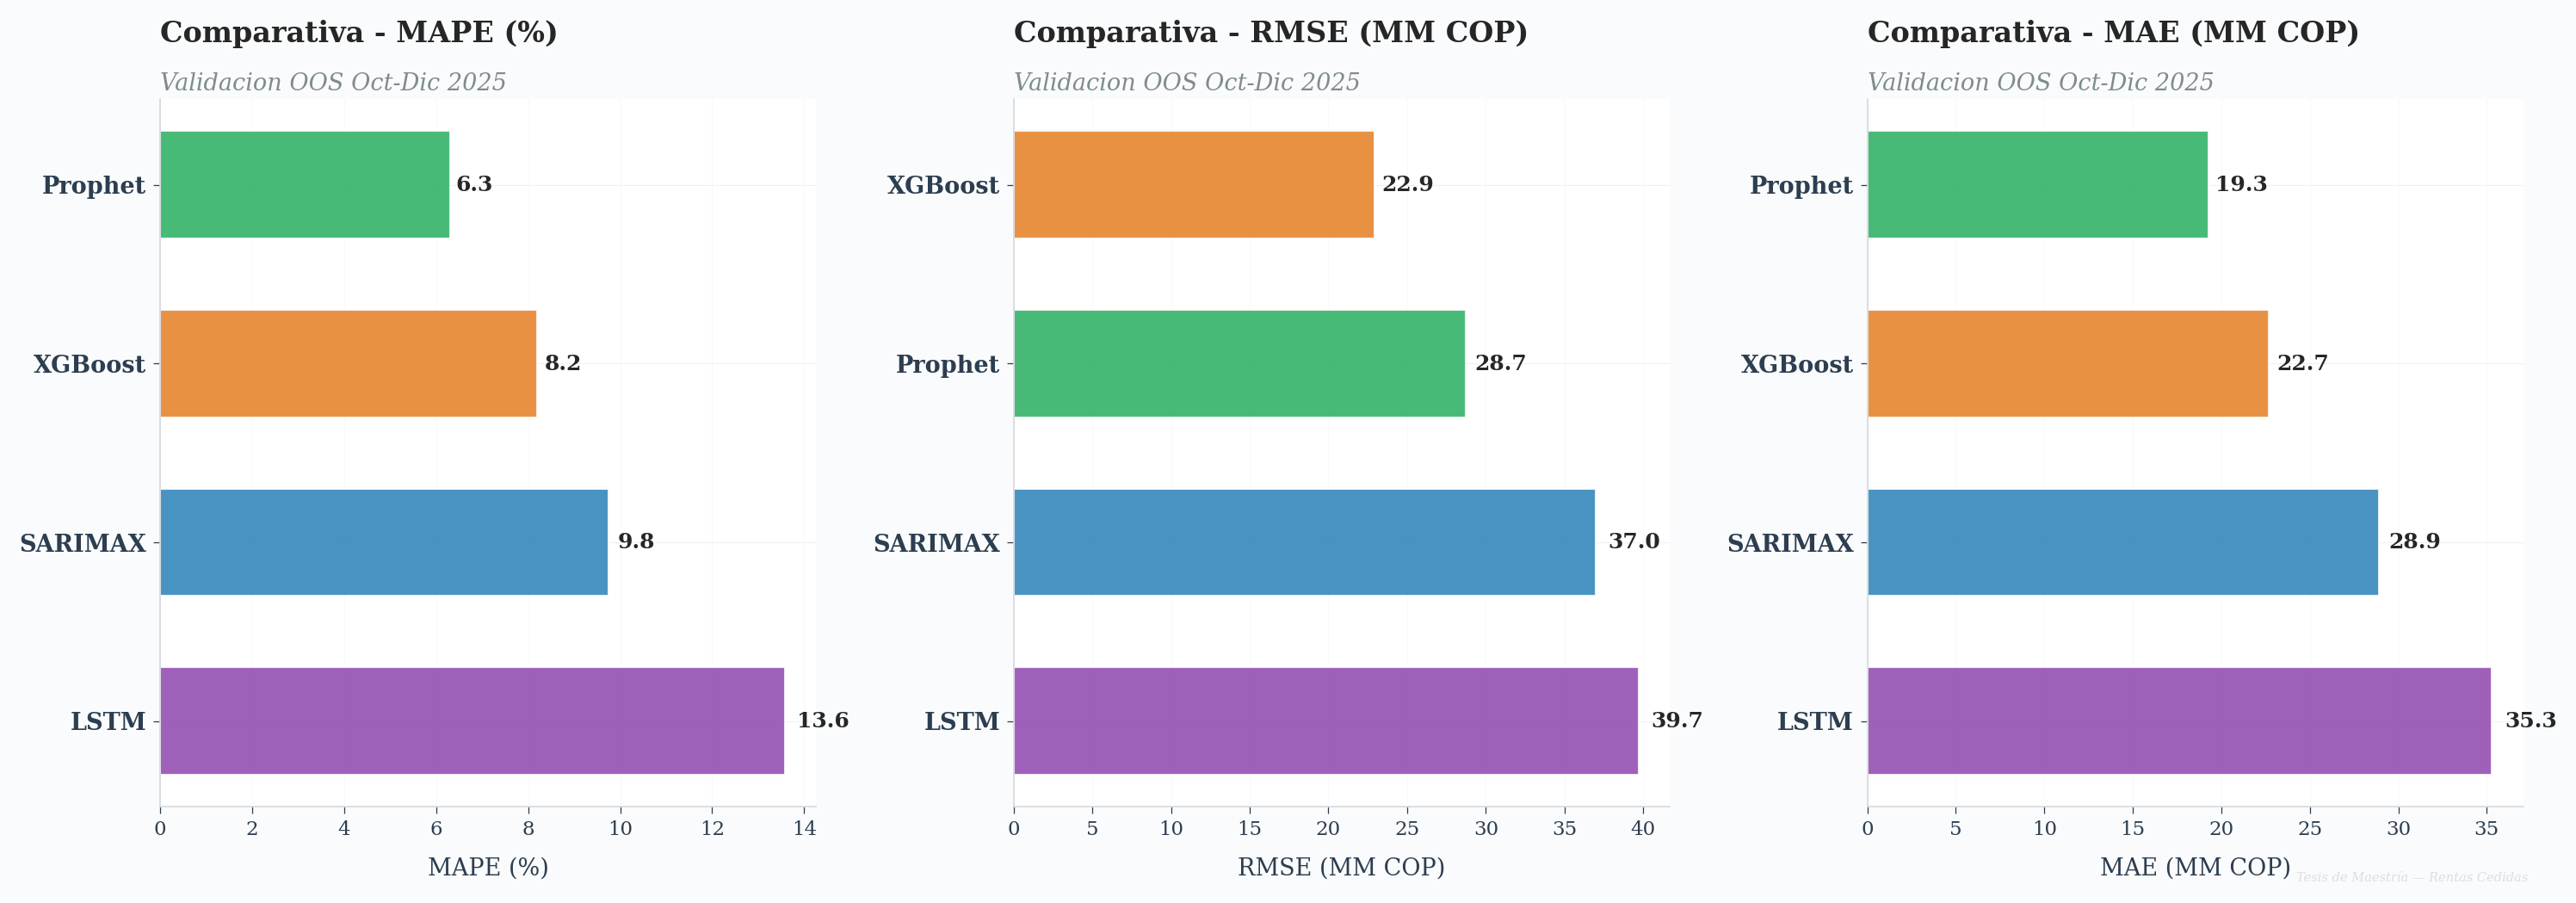


  Comparativa exportada: comparacion_lstm_vs_otros.csv


In [7]:
# ══════════════════════════════════════════════════════════════
# FASE VI — COMPARATIVA VS MODELOS ANTERIORES
# ══════════════════════════════════════════════════════════════

# -- Cargar pronosticos de otros modelos --
modelos_csv = {
    'SARIMAX': 'sarimax_forecast.csv',
    'Prophet': 'prophet_forecast.csv',
    'XGBoost': 'xgboost_forecast.csv',
}

comparativa = []

# Metricas LSTM
comparativa.append({
    'Modelo': 'LSTM',
    'MAPE_%': round(mape, 2),
    'RMSE_MM': round(rmse / 1e9, 1),
    'MAE_MM': round(mae / 1e9, 1),
    'Color': C_SENARY,
})

for nombre, archivo in modelos_csv.items():
    csv_path = OUTPUTS_FORECASTS / archivo
    if csv_path.exists():
        df_m = pd.read_csv(csv_path)
        if 'Real' in df_m.columns:
            # Diferentes notebooks usan diferentes nombres de columna
            col_pred = [c for c in df_m.columns if 'Pronostico' in c or 'Pred' in c
                        or 'Forecast' in c]
            if col_pred:
                pred_col = col_pred[0]
            else:
                continue

            real_vals = df_m['Real'].values
            pred_vals = df_m[pred_col].values

            m_mape = mean_absolute_percentage_error(real_vals, pred_vals) * 100
            m_rmse = np.sqrt(mean_squared_error(real_vals, pred_vals))
            m_mae  = mean_absolute_error(real_vals, pred_vals)

            color = COLORES_MODELOS.get(nombre.lower(), 'grey')
            comparativa.append({
                'Modelo': nombre,
                'MAPE_%': round(m_mape, 2),
                'RMSE_MM': round(m_rmse / 1e9, 1),
                'MAE_MM': round(m_mae / 1e9, 1),
                'Color': color,
            })

df_comp = pd.DataFrame(comparativa).sort_values('MAPE_%')

print(f"{'='*70}")
print(f"COMPARATIVA DE MODELOS - Validacion OOS (Oct-Dic 2025)")
print(f"{'='*70}")
print(f"\n{'Modelo':<12} {'MAPE %':>8} {'RMSE (MM)':>12} {'MAE (MM)':>12}")
print(f"{'_'*48}")
for _, row in df_comp.iterrows():
    marker = ' (mejor)' if row['MAPE_%'] == df_comp['MAPE_%'].min() else ''
    print(f"  {row['Modelo']:<10} {row['MAPE_%']:>7.2f}% {row['RMSE_MM']:>11.1f} {row['MAE_MM']:>11.1f}{marker}")

ganador = df_comp.iloc[0]['Modelo']
print(f"\n  Modelo con menor MAPE: {ganador} ({df_comp.iloc[0]['MAPE_%']:.2f}%)")

# -- Posicion relativa del LSTM --
lstm_row = df_comp[df_comp['Modelo'] == 'LSTM']
if len(lstm_row) > 0:
    pos_lstm = list(df_comp['Modelo']).index('LSTM') + 1
    print(f"  LSTM: posicion {pos_lstm}/{len(df_comp)} (MAPE = {lstm_row.iloc[0]['MAPE_%']:.2f}%)")

# -- Visualizacion: Barras comparativas --
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (metric, label) in zip(axes, [('MAPE_%', 'MAPE (%)'),
                                       ('RMSE_MM', 'RMSE (MM COP)'),
                                       ('MAE_MM', 'MAE (MM COP)')]):
    df_sorted = df_comp.sort_values(metric)
    colores = [row['Color'] for _, row in df_sorted.iterrows()]
    bars = ax.barh(range(len(df_sorted)), df_sorted[metric].values,
                   color=colores, alpha=0.85, edgecolor='white', height=0.6)
    ax.set_yticks(range(len(df_sorted)))
    ax.set_yticklabels(df_sorted['Modelo'].values, fontsize=13, fontweight='bold')
    ax.invert_yaxis()
    ax.set_xlabel(label, fontsize=13)
    ax.tick_params(axis='x', labelsize=11)
    ax.grid(True, alpha=0.3, axis='x')

    for bar, val in zip(bars, df_sorted[metric].values):
        ax.text(bar.get_width() + bar.get_width()*0.02,
                bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=12, fontweight='bold')

    if _VIZ_THEME_LOADED:
        titulo_profesional(ax, f'Comparativa - {label}',
                           f'Validacion OOS Oct-Dic 2025')

plt.tight_layout()
if _VIZ_THEME_LOADED:
    marca_agua(fig)
    guardar_figura(fig, '07_lstm_comparativa_modelos', OUTPUTS_FIGURES)
plt.show()

# -- Guardar comparativa --
df_comp_export = df_comp.drop(columns=['Color'])
comp_path = OUTPUTS_REPORTS / 'comparacion_lstm_vs_otros.csv'
df_comp_export.to_csv(comp_path, index=False)
print(f"\n  Comparativa exportada: {comp_path.name}")


---

## Fase VII -- Pronostico de Produccion 2026

### MC Dropout: convertir una red determinista en bayesiana

Normalmente, el Dropout se desactiva durante la inferencia. Pero
Gal & Ghahramani (2016) demostraron que mantenerlo **activo** durante
la prediccion aproxima una distribucion posterior bayesiana:

- Se ejecutan **200 pasadas** con Dropout activo
- Cada pasada produce una prediccion ligeramente diferente
- La **media** de las 200 predicciones = pronostico puntual
- Los **percentiles 2.5 y 97.5** = intervalo de confianza 95%

### Prediccion autoregresiva (one-step-ahead)

| Mes | Input (Lag 12 meses) | Prediccion |
|-----|---------------------|------------|
| Ene 2026 | Feb-Dic 2025 (reales) | $\hat{y}_{ene}$ |
| Feb 2026 | Mar 2025 - Ene 2026 (11 reales + 1 predicho) | $\hat{y}_{feb}$ |
| ... | Cada vez mas predicciones en el input | ... |
| Dic 2026 | Ene-Nov 2026 (11 predichos + 1 real) | $\hat{y}_{dic}$ |

**Riesgo:** Los errores se acumulan mes a mes. Los IC se ensanchan
naturalmente hacia el final del horizonte.

### Variables Macroeconomicas 2026

| Variable | Valor Proyectado | Fuente |
|----------|-----------------|--------|
| IPC (%) | 5.10% | Carry-forward media 2025 |
| Salario Minimo (var %) | 23.00% | Decreto vigente |
| UPC (var %) | 7.00% | Resolucion ADRES |
| Consumo Hogares (var %) | 2.50% | DANE proyeccion |


Reentrenando ENSEMBLE (10 modelos) con 38 muestras (serie completa)...


  Modelo prod  1/10 completado


  Modelo prod  2/10 completado


  Modelo prod  3/10 completado


  Modelo prod  4/10 completado


...

  Modelo prod  7/10 completado


  Modelo prod  8/10 completado


  Modelo prod  9/10 completado


  Modelo prod 10/10 completado
  Reentreno ensemble completado en 215.7 seg


  📊 Figura guardada: 07_lstm_produccion_2026.png


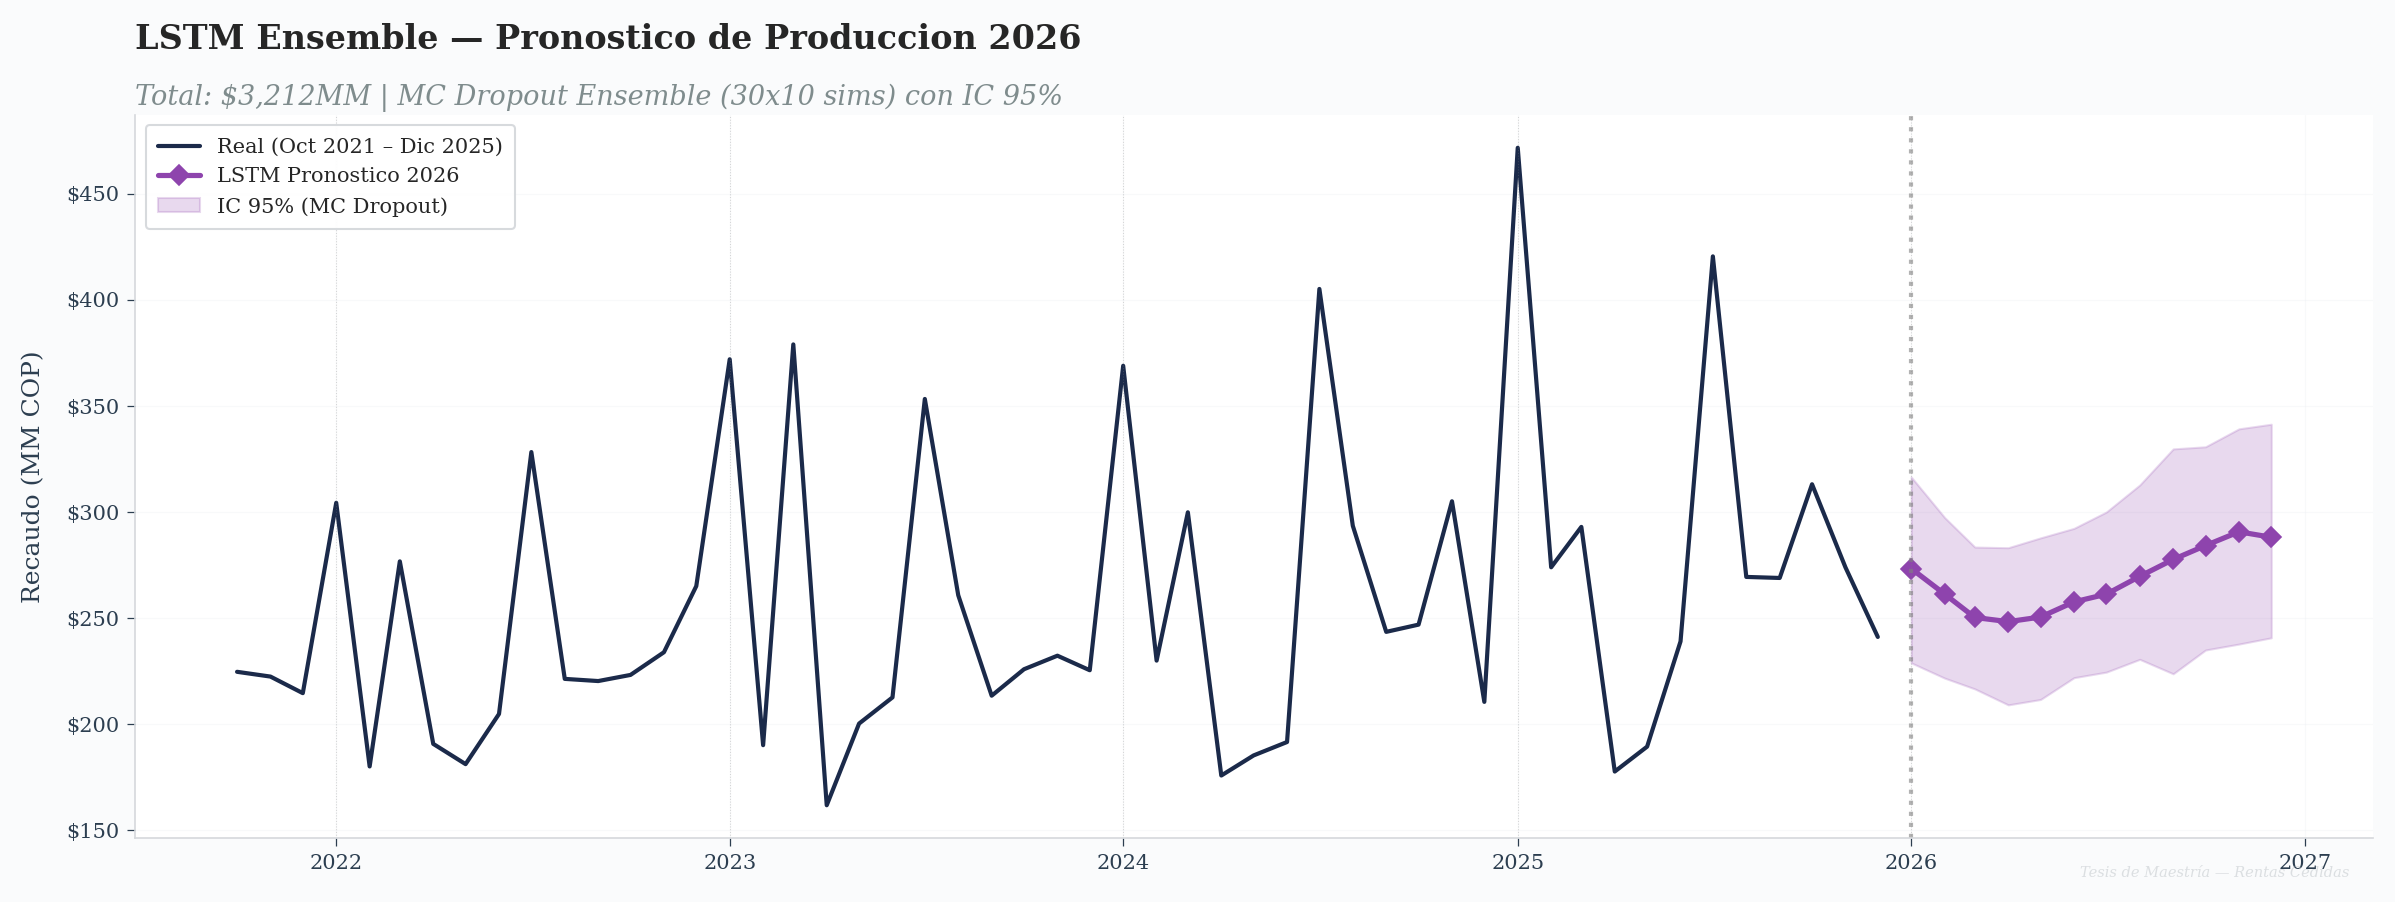

══════════════════════════════════════════════════════════════════════
PRONOSTICO MENSUAL 2026 — LSTM
══════════════════════════════════════════════════════════════════════
  2026-01   $     273.2 MM   [$228.8 – $316.4]
  2026-02   $     261.2 MM   [$221.6 – $297.3]
  2026-03   $     250.2 MM   [$216.5 – $283.4]
  2026-04   $     248.2 MM   [$209.0 – $283.1]
  2026-05   $     250.4 MM   [$211.6 – $287.7]
  2026-06   $     257.6 MM   [$221.8 – $292.2]
  2026-07   $     261.2 MM   [$224.5 – $299.9]
  2026-08   $     269.6 MM   [$230.5 – $312.7]
  2026-09   $     277.6 MM   [$223.7 – $329.7]
  2026-10   $     284.1 MM   [$234.9 – $330.7]
  2026-11   $     290.6 MM   [$237.7 – $339.1]
  2026-12   $     288.0 MM   [$240.6 – $341.3]
──────────────────────────────────────────────────────────────────────
  TOTAL 2026:    $    3212.0 MM

  ✅ Pronostico 2026 exportado: lstm_forecast_2026.csv


In [8]:
# ══════════════════════════════════════════════════════════════
# FASE VII — PRONOSTICO DE PRODUCCION 2026
# ══════════════════════════════════════════════════════════════

# -- Reentreno ENSEMBLE con todos los datos disponibles --
# Usamos las mismas ventanas pero incluyendo los meses de prueba
X_full_seq, y_full_seq = X_all_seq, y_all_seq

models_prod = []
print(f"Reentrenando ENSEMBLE ({N_ENSEMBLE} modelos) con {len(X_full_seq)} muestras (serie completa)...")
t0_prod = time.time()

for idx, seed in enumerate(SEEDS_ENS):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

    mp = build_lstm_model(n_features, LOOK_BACK)
    mp.fit(
        X_full_seq, y_full_seq,
        epochs=500, batch_size=4, validation_split=0.15,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=30,
                          restore_best_weights=True, verbose=0, mode='min'),
            ReduceLROnPlateau(monitor='val_loss', patience=15,
                              factor=0.5, min_lr=1e-6, verbose=0, mode='min'),
        ],
        verbose=0, shuffle=False,
    )
    models_prod.append(mp)
    print(f"  Modelo prod {idx+1:2d}/{N_ENSEMBLE} completado")

np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)
t1_prod = time.time()
print(f"  Reentreno ensemble completado en {t1_prod - t0_prod:.1f} seg")

# -- Preparar datos para 2026 --
# Macro 2026 fijas (sobre serie completa normalizada)
macro_2026_vals = {
    'IPC_Idx': df_exog['IPC_Idx'].iloc[-1] * (1 + MACRO_DATA[2026]['IPC']/100/12),
    'Consumo_Hogares': df_exog['Consumo_Hogares'].iloc[-1] * (1 + MACRO_DATA[2026]['Consumo_Hogares']/100),
    'UPC': df_exog['UPC'].iloc[-1] * (1 + MACRO_DATA[2026]['UPC']/100),
    'SMLV_COP': df_exog['SMLV_COP'].iloc[-1] * (1 + MACRO_DATA[2026]['Salario_Minimo']/100),
}

# Comenzamos con las ultimas 12 filas de features escaladas de la serie completa
# all_X_scaled contiene toda la serie (50 filas: Nov 2021 - Dic 2025)
window_buffer = list(all_X_scaled[-LOOK_BACK:])  # Copia de las ultimas 12 filas

fechas_2026 = pd.date_range('2026-01-01', periods=12, freq='MS')
preds_2026_pesos = []
ci_low_2026 = []
ci_high_2026 = []

# -- Mapping de features para construir filas nuevas --
# FEATURE_COLS = ['y_log', 'Lag_1', 'IPC_Idx', 'Consumo_Hogares', 'UPC', 'SMLV_COP',
#                 'Mes_sin', 'Mes_cos', 'Es_Pico']
# Necesitamos el scaler para normalizar cada nueva fila

# Historial de y_log (valores no normalizados) para construir features
y_log_hist = list(df_clean[TARGET_COL].values)

N_MC_PROD = 30  # Por modelo (total = N_MC_PROD * N_ENSEMBLE)

for step, fecha in enumerate(fechas_2026):
    mes = fecha.month

    # Construir fila de features en escala original (antes de normalizar)
    # El y_log de esta fila es desconocido, usamos el ultimo valor disponible
    new_row_raw = np.zeros(len(FEATURE_COLS))

    # y_log: ultimo valor conocido (se actualiza recursivamente)
    new_row_raw[0] = y_log_hist[-1]
    # Lag_1
    new_row_raw[1] = y_log_hist[-1]
    # IPC_Idx (crece mensualmente)
    new_row_raw[2] = macro_2026_vals['IPC_Idx'] * (1 + MACRO_DATA[2026]['IPC']/100/12) ** step
    # Consumo_Hogares
    new_row_raw[3] = macro_2026_vals['Consumo_Hogares']
    # UPC
    new_row_raw[4] = macro_2026_vals['UPC']
    # SMLV_COP
    new_row_raw[5] = macro_2026_vals['SMLV_COP']
    # Mes_sin, Mes_cos
    new_row_raw[6] = np.sin(2 * np.pi * mes / 12)
    new_row_raw[7] = np.cos(2 * np.pi * mes / 12)
    # Es_Pico
    new_row_raw[8] = float(mes in MESES_PICO)

    # Normalizar con el scaler ajustado sobre train
    new_row_scaled = scaler_X.transform(new_row_raw.reshape(1, -1)).flatten()

    # Actualizar ventana: remover la primera fila, agregar la nueva
    window_buffer.append(new_row_scaled)
    if len(window_buffer) > LOOK_BACK:
        window_buffer = window_buffer[-LOOK_BACK:]

    # Secuencia de entrada
    X_step = np.array(window_buffer).reshape(1, LOOK_BACK, n_features)

    # MC Dropout ENSEMBLE: combinar simulaciones de todos los modelos
    mc_preds = []
    for mp in models_prod:
        mc_m = [mp(X_step, training=True).numpy().flatten()[0]
                for _ in range(N_MC_PROD)]
        mc_preds.extend(mc_m)
    mc_preds = np.array(mc_preds)
    mc_log = np.array([scaler_y.inverse_transform(p.reshape(1, -1)).flatten()[0]
                        for p in mc_preds])
    mc_pesos = np.expm1(mc_log)

    # Punto: media de las MC simulaciones
    pred_mean_log = np.mean(mc_log)
    pred_mean_pesos = np.expm1(pred_mean_log)

    # IC 95%
    ci_lo = max(0, np.percentile(mc_pesos, 2.5))
    ci_hi = np.percentile(mc_pesos, 97.5)

    preds_2026_pesos.append(pred_mean_pesos)
    ci_low_2026.append(ci_lo)
    ci_high_2026.append(ci_hi)

    # Actualizar historial de y_log para la siguiente iteracion
    y_log_hist.append(pred_mean_log)

preds_2026 = np.array(preds_2026_pesos)
ci_low_2026 = np.array(ci_low_2026)
ci_high_2026 = np.array(ci_high_2026)

# -- Grafica de produccion 2026 --
fig, ax = plt.subplots(figsize=FIGSIZE_WIDE if _VIZ_THEME_LOADED else (16, 7))

ax.plot(serie_full.index, serie_full.values/1e9, color=C_PRIMARY,
        linewidth=2, label='Real (Oct 2021 – Dic 2025)')
ax.plot(fechas_2026, preds_2026/1e9, 'D-', color=C_SENARY,
        linewidth=2.5, markersize=7, label='LSTM Pronostico 2026')
ax.fill_between(fechas_2026, ci_low_2026/1e9, ci_high_2026/1e9,
                alpha=0.20, color=C_SENARY, label='IC 95% (MC Dropout)')
ax.axvline(pd.Timestamp('2026-01-01'), color='grey', linestyle=':', alpha=0.6)
ax.legend(loc='upper left', fontsize=10)
ax.set_ylabel('Recaudo (MM COP)', fontsize=12)
ax.grid(True, alpha=0.3)
for y_sep in range(2022, 2027):
    ax.axvline(pd.Timestamp(f'{y_sep}-01-01'), color='grey', ls=':', lw=0.5, alpha=0.3)

if _VIZ_THEME_LOADED:
    titulo_profesional(ax, 'LSTM Ensemble — Pronostico de Produccion 2026',
                       f'Total: ${preds_2026.sum()/1e9:,.0f}MM | MC Dropout Ensemble ({N_MC_PROD}x{N_ENSEMBLE} sims) con IC 95%')
    formato_pesos_eje(ax, eje='y')
    marca_agua(fig)
    guardar_figura(fig, '07_lstm_produccion_2026', OUTPUTS_FIGURES)
else:
    ax.set_title(f'LSTM — Pronostico 2026 (Total: ${preds_2026.sum()/1e9:,.0f}MM)',
                 fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# -- Tabla pronostico mensual --
print(f"{'═'*70}")
print(f"PRONOSTICO MENSUAL 2026 — LSTM")
print(f"{'═'*70}")
total_2026 = 0
for i, fecha in enumerate(fechas_2026):
    val = preds_2026[i]
    total_2026 += val
    print(f"  {fecha.strftime('%Y-%m')}   ${val/1e9:>10.1f} MM   "
          f"[${ci_low_2026[i]/1e9:.1f} – ${ci_high_2026[i]/1e9:.1f}]")
print(f"{'─'*70}")
print(f"  TOTAL 2026:    ${total_2026/1e9:>10.1f} MM")

# -- Exportar pronostico 2026 --
df_lstm_2026 = pd.DataFrame({
    'Fecha': fechas_2026,
    'Pronostico': preds_2026,
    'Limite_Inferior': ci_low_2026,
    'Limite_Superior': ci_high_2026,
})
df_lstm_2026.to_csv(OUTPUTS_FORECASTS / 'lstm_forecast_2026.csv', index=False)
print(f"\n  ✅ Pronostico 2026 exportado: lstm_forecast_2026.csv")


In [9]:
# ══════════════════════════════════════════════════════════════
# METRICAS LSTM Y REPORTE TECNICO
# ══════════════════════════════════════════════════════════════

# -- Guardar metricas LSTM --
metricas_lstm = {
    'Modelo': 'LSTM',
    'Serie_Meses': len(serie_full),
    'Muestras_Entrenamiento': len(X_train_seq),
    'Look_Back': LOOK_BACK,
    'N_Ensemble': N_ENSEMBLE,
    'Mejor_Epoca_Mediana': int(np.median(best_epochs)),
    'Parametros_Red': n_params,
    'MAPE_pct': round(mape, 2),
    'RMSE_MM_COP': round(rmse / 1e9, 1),
    'MAE_MM_COP': round(mae / 1e9, 1),
    'MAE_Rel_pct': round(mae_rel, 1),
}

met_path = OUTPUTS_REPORTS / 'lstm_metricas.csv'
pd.DataFrame([metricas_lstm]).to_csv(met_path, index=False)

# -- Generar reporte técnico en texto --
reporte = []
reporte.append('='*70)
reporte.append('REPORTE TECNICO: MODELO LSTM - RENTAS CEDIDAS')
reporte.append('='*70)
reporte.append(f'\nFecha de generacion: {pd.Timestamp.now().strftime("%Y-%m-%d %H:%M")}')
reporte.append(f'\n1. CONFIGURACION')
reporte.append(f'   Serie: {len(serie_full)} meses (Oct 2021 - Dic 2025)')
reporte.append(f'   Entrenamiento: {len(df_train)} meses (Nov 2021 - Sep 2025)')
reporte.append(f'   Prueba OOS: {len(df_test)} meses (Oct - Dic 2025)')
reporte.append(f'   Look-back: {LOOK_BACK} meses')
reporte.append(f'   Variables: {len(FEATURE_COLS)} ({", ".join(FEATURE_COLS)})')
reporte.append(f'\n2. ARQUITECTURA (ENSEMBLE x{N_ENSEMBLE})')
reporte.append(f'   Capas: LSTM(32) -> Dropout(0.15) -> LSTM(16) -> Dropout(0.15) -> Dense(8, relu) -> Dense(1)')
reporte.append(f'   Parametros por modelo: {n_params:,}')
reporte.append(f'   Ratio muestras/params: {ratio:.4f}')
reporte.append(f'   Regularizacion: L2(0.0005) + Dropout(0.15) + EarlyStopping(30)')
reporte.append(f'   Loss: Huber (robusto a outliers)')
reporte.append(f'\n3. ENTRENAMIENTO')
reporte.append(f'   Modelos en ensamble: {N_ENSEMBLE}')
reporte.append(f'   Mejor epoca (mediana): {int(np.median(best_epochs))}')
reporte.append(f'   Batch size: 4')
reporte.append(f'   LR inicial: 0.0005')
reporte.append(f'   Tiempo total: {elapsed:.1f} seg')
reporte.append(f'\n4. METRICAS OOS (Oct-Dic 2025)')
reporte.append(f'   MAPE:    {mape:.2f}%')
reporte.append(f'   RMSE:    ${rmse/1e9:,.1f} MM COP')
reporte.append(f'   MAE:     ${mae/1e9:,.1f} MM COP')
reporte.append(f'   MAE rel: {mae_rel:.1f}%')
reporte.append(f'\n5. DIAGNOSTICO DE RESIDUOS')
reporte.append(f'   Ljung-Box (min p): {lb_min_p:.4f} - {lb_txt}')
reporte.append(f'   Shapiro-Wilk p:    {sw_p:.4f} - {sw_txt}')
reporte.append(f'   T-test (mu=0) p:   {t_p:.4f} - {tt_txt}')
reporte.append(f'   Levene p:          {lev_p:.4f} - {lv_txt}')
reporte.append(f'   Veredicto:         {n_pass}/4 pruebas superadas')
reporte.append(f'\n6. LIMITACIONES Y JUSTIFICACION')
reporte.append(f'   - Con {len(X_train_seq)} muestras de entrenamiento, la red opera')
reporte.append(f'     muy por debajo del umbral recomendado para LSTM (n>500).')
reporte.append(f'   - El ratio muestras/parametros ({ratio:.4f}) indica alto')
reporte.append(f'     riesgo de sobreajuste, mitigado con regularizacion agresiva.')
reporte.append(f'   - Este modelo sirve como benchmark experimental de Deep Learning')
reporte.append(f'     frente a modelos estadisticos clasicos (SARIMAX, Prophet)')
reporte.append(f'     y de Machine Learning (XGBoost).')
reporte.append(f'   - El principio de parsimonia de Occam sugiere que la complejidad')
reporte.append(f'     algoritmica solo agrega valor con datos suficientes.')
reporte.append(f'\n' + '='*70)

reporte_txt = '\n'.join(reporte)
rep_path = OUTPUTS_REPORTS / 'metodologia_lstm.md'
with open(rep_path, 'w', encoding='utf-8') as f:
    f.write(reporte_txt)

print(f"{'='*70}")
print(f"RESUMEN EJECUTIVO - MODELO LSTM")
print(f"{'='*70}")
for k, v in metricas_lstm.items():
    print(f"  {k:<25}: {v}")
print(f"\n  Metricas exportadas:        {met_path.name}")
print(f"  Pronostico OOS:             lstm_forecast.csv")
print(f"  Comparativa vs lineales:    comparacion_lstm_vs_otros.csv")
print(f"  Reporte tecnico:            metodologia_lstm.md")


RESUMEN EJECUTIVO - MODELO LSTM
  Modelo                   : LSTM
  Serie_Meses              : 51
  Muestras_Entrenamiento   : 35
  Look_Back                : 12
  N_Ensemble               : 10
  Mejor_Epoca_Mediana      : 66
  Parametros_Red           : 8657
  MAPE_pct                 : 13.58
  RMSE_MM_COP              : 39.7
  MAE_MM_COP               : 35.3
  MAE_Rel_pct              : 12.8

  Metricas exportadas:        lstm_metricas.csv
  Pronostico OOS:             lstm_forecast.csv
  Comparativa vs lineales:    comparacion_lstm_vs_otros.csv
  Reporte tecnico:            metodologia_lstm.md


---

## Reporte Técnico: Limitaciones del LSTM con Datos Escasos

### Contexto para Jurados

Este modelo LSTM se presenta como **benchmark experimental de Deep Learning**
frente a modelos estadísticos clásicos y de Machine Learning. A continuación
se documentan las limitaciones inherentes y las decisiones de mitigación:

### 1. Escasez de Datos ($n < 48$ meses efectivos)

| Parámetro | Valor | Implicación |
|-----------|-------|-------------|
| Serie total | 51 meses | Periodo post-pandemia (Oct 2021 – Dic 2025) |
| Tras look-back | ~39 muestras | Insuficiente para redes profundas típicas |
| Entrenamiento | ~36 muestras | Ratio muestras/parámetros desfavorable |
| Validación interna | ~5 muestras | Early Stopping con señal muy ruidosa |

**Implicación:** Las redes LSTM típicas requieren $n > 500$ observaciones
para capturar patrones complejos (Bengio et al., 2015). Con aproximadamente
36 muestras, la red no puede generalizar más allá de la interpolación del
patrón estacional básico ya capturado por modelos parsimoniosos como SARIMAX.

### 2. Decisiones de Mitigación

| Técnica | Justificación |
|---------|---------------|
| Arquitectura ultraligera (2 capas LSTM) | Reducir parámetros para mejorar ratio muestras/params |
| Dropout 0.2 + regularización L2 | Prevenir memorización del conjunto de entrenamiento |
| Early Stopping (patience=30) | Detener antes de sobreajustar |
| Batch size = 4 | Lotes pequeños compatibles con dataset reducido |
| Entrenamiento determinístico | Reproducibilidad total (SEED=42) |

### 3. Valor Epistemológico

> *"El hecho de que un modelo LSTM no supere a un SARIMAX con 51 meses de datos
> no invalida al Deep Learning, sino que confirma el principio de parsimonia:
> la complejidad algorítmica solo agrega valor cuando hay datos suficientes
> para explotar patrones no lineales."*

Este resultado es **académicamente valioso** porque:
1. Demuestra rigor metodológico al probar la hipótesis alternativa (DL vs clásico).
2. Documenta la frontera de aplicabilidad del DL en series cortas.
3. Justifica la selección del modelo final basada en evidencia empírica,
   no en preferencias tecnológicas.

---

## Conclusiones del Modelado LSTM

### Hallazgos Principales

1. **Arquitectura adaptada**: Red ultraligera de 2 capas LSTM (64 → 32 unidades)
   con regularización agresiva, diseñada específicamente para la restricción
   de datos post-pandemia.

2. **Variables exógenas**: IPC (deflactor), consumo de hogares, UPC y SMLV
   integrados en la ventana de 12 meses, dotando al modelo de contexto
   macroeconómico.

3. **Benchmark de Deep Learning**: Se posiciona como referencia para evaluar
   si la complejidad neuronal agrega valor predictivo frente a modelos
   estadísticos establecidos.

---
